# Final Project

This project is a compilation of techniques learned in the Social Data Analysis and Visualization course (02806).  Using open data from New York City, specifically restaurant inspection data, it analyzes our biases toward different restaurants. Further details will be explained in the following sections.


* Setup
* Motivation
* Basic Stats
* Data Analysis
* Genre
* Visualizations
* Discussion
* Contribtuions

---
## 0 Setup

In [1]:
import pandas as pd
# ═══════════════════════════════════════════════════════════════════════════════
# GLOBAL STYLE SETUP  (run once at top of notebook)
# Tufte / DAOST — high data-ink ratio, minimal chrome
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

# ── Typography ─────────────────────────────────────────────────────────────────
plt.rcParams['font.family']           = 'sans-serif'
plt.rcParams['font.sans-serif']       = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus']    = False
plt.rcParams['font.size']             = 11          # base size everything scales from
plt.rcParams['axes.titlesize']        = 12
plt.rcParams['axes.titleweight']      = 'bold'
plt.rcParams['axes.titlepad']         = 10
plt.rcParams['axes.labelsize']        = 10
plt.rcParams['axes.labelcolor']       = '#333333'
plt.rcParams['xtick.labelsize']       = 9
plt.rcParams['ytick.labelsize']       = 9
plt.rcParams['legend.fontsize']       = 9
plt.rcParams['figure.titlesize']      = 14
plt.rcParams['figure.titleweight']    = 'normal'    # suptitle stays light

# ── Spines & Ticks ─────────────────────────────────────────────────────────────
plt.rcParams['axes.spines.top']       = False
plt.rcParams['axes.spines.right']     = False
plt.rcParams['axes.spines.left']      = True
plt.rcParams['axes.spines.bottom']    = True
plt.rcParams['axes.edgecolor']        = '#cccccc'   # soft spine colour
plt.rcParams['axes.linewidth']        = 0.8
plt.rcParams['xtick.color']           = '#555555'
plt.rcParams['ytick.color']           = '#555555'
plt.rcParams['xtick.direction']       = 'out'
plt.rcParams['ytick.direction']       = 'out'
plt.rcParams['xtick.major.size']      = 4
plt.rcParams['ytick.major.size']      = 4
plt.rcParams['xtick.major.width']     = 0.8
plt.rcParams['ytick.major.width']     = 0.8

# ── Grid ───────────────────────────────────────────────────────────────────────
plt.rcParams['axes.grid']             = True
plt.rcParams['grid.color']            = '#eeeeee'
plt.rcParams['grid.linewidth']        = 0.8
plt.rcParams['grid.linestyle']        = '-'
plt.rcParams['axes.axisbelow']        = True        # grid behind bars

# ── Figures ────────────────────────────────────────────────────────────────────
plt.rcParams['figure.facecolor']      = 'white'
plt.rcParams['axes.facecolor']        = 'white'
plt.rcParams['figure.dpi']            = 120
plt.rcParams['savefig.dpi']           = 150
plt.rcParams['savefig.bbox']          = 'tight'
plt.rcParams['savefig.facecolor']     = 'white'

# ── Legend ─────────────────────────────────────────────────────────────────────
plt.rcParams['legend.frameon']        = False       # no box
plt.rcParams['legend.loc']            = 'best'

# ── Semantic palette (reuse everywhere) ────────────────────────────────────────
GRADE_COLORS  = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c"}
DARK          = "#2c3e50"       # main data ink (lines, markers)
SPINE_COLOR   = "#cccccc"
TICK_COLOR    = "#555555"
BORO_ORDER    = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]

---
## 1 Motivation

### 1.1 What is your dataset?

Our project uses the New York City Restaurant Inspection Results dataset, which was published by the Department of Health and Mental Hygiene (DOHMH) on NYC OpenData [1]. The dataset includes all violations cited during full or special-program inspections at active NYC restaurants and college cafeterias within three years of the most recent data extraction, whether sustained or not yet adjudicated. The dataset is updated daily, providing a near real-time snapshot of food-safety enforcement across the city's five boroughs. Each establishment is identified by a unique CAMIS number. Each row represents a single violation and its associated metadata, including the restaurant's cuisine type, geographic coordinates, borough, ZIP code, inspection score, and letter grade (A, B, or C). Since July 27, 2010, the letter grading program has awarded an "A" for scores below 14, a "B" for scores between 14 and 27, and a "C" for scores of 28 or higher.

### 1.2 Why did we choose this dataset?

We selected the DOHMH NYC Restaurant Inspection Results dataset because it reveals a universal cognitive bias: we judge the cleanliness of a restaurant without consulting the data. People rely on unconscious cues, such as ambiance, price, cuisine type, and neighborhood, to decide where to eat. They replace the difficult question, "How hygienic is this kitchen?" with the easier question, "Does this place look clean?"

This dataset is powerful for combating bias due to its scope and objectivity. It covers tens of thousands of active restaurants across all five boroughs and classifies them by more than 80 types of cuisine. Trained health inspectors assign each restaurant a standardized inspection score, regardless of its décor or price. Because cuisine type serves as a proxy for cultural and ethnic identity, the dataset implicitly encodes the kinds of stereotypes that are most important to examine. If the scores of distrusted cuisines are comparable to or better than those of favored ones, this provides a direct, data-driven rebuttal to a bias that shapes the daily choices of millions.

### 1.3 What was our goal for the end user's experience?

Our goal was to evoke an emotional response from the reader and then present data that contradicts it. The experience is designed in two acts. First, we activate the reader's intuitions about which restaurants they trust and why. Then, we present the inspection results, which reveal patterns that contradict their expectations.

Readers can test their assumptions by exploring the types of cuisine and neighborhoods about which they have personal opinions, as the interactivity is purposely designed this way. Our intention is not to shame readers, but rather to leave them with more calibrated instincts and an awareness that their perception of hygiene is driven by signals that have little to do with what is actually happening in the kitchen.

---
##  2  Basic stats. Let's understand the dataset better


### 2.1 Write about your choices in data cleaning and preprocessing

Several targeted cleaning decisions were necessary for the raw dataset before it could be analyzed. First, we removed all records with an inspection date of January 1, 1900. The DOHMH uses this date as a placeholder for restaurants that have applied for a permit but have not yet been inspected. Next, we restricted the data to graded inspections conducted between July 27, 2010 (the start date of the letter grading program) and December 31, 2025. Using the same logic, we eliminated rows with no valid A, B, or C grade and kept only the four inspection types that the DOHMH considers gradable. Because the borough is central to our geographic analysis, we removed the small number of records with invalid borough codes (coded as "0"). Missing values in the ZIP code, latitude, longitude, and community-level fields were left untouched because borough-level information is complete for every row. The 258 missing VIOLATION CODE and VIOLATION DESCRIPTION entries correspond to inspections where no violations were cited; therefore, these entries were retained.

A more fundamental issue emerged from the dataset itself. According to DOHMH documentation, the published file only includes inspections from active restaurants from the past three years. This means that closed establishments are entirely removed, and pre-2022 inspections are residual rather than representative. Therefore, a 2026 extraction cannot address historical questions, and any pre-Covid comparison would favor surviving establishments. To recover that history, we obtained an archived 2019 [2] snapshot of the same dataset and merged it with the 2026 file. We applied the same cleaning process to both snapshots and concatenated them using a temporal split on August 10, 2019, the last inspection date in the 2019 file. This ensured that no inspection was double-counted. We also harmonized the cuisine labels between the two snapshots because the DOHMH renamed several categories (e.g., "Café/Coffee/Tea" became "Coffee/Tea," and "Steak" became "Steakhouse"). Since letter grading was paused from March 17, 2020, to July 19, 2021, due to the COVD-19 emergency, we created additional versions that excluded the pause. This was done to prevent time-series or modeling work from being distorted by the gap.

This pipeline produces four working datasets. The first two, df_2026 and df_2026_no_covid, are used for cross-sectional analyses describing the current state of dining in New York City (NYC). These analyses are based on 120,310 restaurant inspections. The latter two datasets, df_merged and df_merged_no_covid, are used for historical comparisons . These analyses are based on 305,128 inspections of 37,050 restaurants from 2012 to 2025. Of those restaurants, 14,018 only appear in the 2019 snapshot. These are establishments that have since closed and would otherwise be invisible. They provide the survivorship bias correction necessary for meaningful pre- and post-Covid comparisons. There is one exception to this pipeline that applies to two specific analyses. The initial-versus-reinspection slope chart requires initial and reinspection scores from the same restaurant within the same cycle. Since the cleaning pipeline requires a valid A, B, or C grade, reinspections resulting in a pending grade are discarded before they can be paired with their initial inspection. For this reason, the slope chart is built directly from df26_raw, with only the placeholder dates and invalid borough codes removed. This preserves the full two-step inspection cycle. Similarly, the EDA cuisine overview dot plot uses raw data to display the full score range across all inspection types. Using cleaned data collapses all medians into the A-grade range, obscuring the variation between cuisines that motivated selecting the eight cuisines for analysis.


In [2]:
# Inspection — Compare the 2019 and 2026 snapshots BEFORE merging.
# Goal: understand what each file contains, what's compatible, and what isn't.

import pandas as pd

# ── Load both ───────────────────────────────────────────────────────────────
df19 = pd.read_csv("data/NewYorkCity_Restaurant_Inspection_Results_2019.csv",
                   dtype={"ZIPCODE": str}, low_memory=False)
df26 = pd.read_csv("data/NewYorkCity_Restaurant_Inspection_Results_2026.csv",
                   dtype={"ZIPCODE": str}, low_memory=False)

# Parse dates uniformly
for d in (df19, df26):
    d["INSPECTION DATE"] = pd.to_datetime(d["INSPECTION DATE"], errors="coerce")

print("=" * 70)
print("BASIC SHAPE")
print("=" * 70)
print(f"2019 file: {len(df19):>9,} rows × {df19.shape[1]} columns")
print(f"2026 file: {len(df26):>9,} rows × {df26.shape[1]} columns")

# ── Column comparison ──────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("COLUMN DIFFERENCES")
print("=" * 70)
cols19 = set(df19.columns)
cols26 = set(df26.columns)
print(f"In BOTH files     ({len(cols19 & cols26)} cols): {sorted(cols19 & cols26)}")
print(f"\nONLY in 2019 file ({len(cols19 - cols26)} cols): {sorted(cols19 - cols26)}")
print(f"\nONLY in 2026 file ({len(cols26 - cols19)} cols): {sorted(cols26 - cols19)}")

# ── Date coverage ───────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("INSPECTION DATE COVERAGE")
print("=" * 70)
for name, d in [("2019", df19), ("2026", df26)]:
    valid = d["INSPECTION DATE"].dropna()
    valid = valid[valid != pd.Timestamp("1900-01-01")]
    print(f"{name} file: {valid.min().date()} → {valid.max().date()}    "
          f"({len(valid):,} non-placeholder rows)")

print("\nRows per year, side-by-side:")
y19 = df19["INSPECTION DATE"].dt.year.value_counts().sort_index()
y26 = df26["INSPECTION DATE"].dt.year.value_counts().sort_index()
year_compare = pd.concat([y19, y26], axis=1, keys=["2019_file", "2026_file"]).fillna(0).astype(int)
print(year_compare)

# ── Restaurant overlap (by CAMIS) ───────────────────────────────────────────
print("\n" + "=" * 70)
print("RESTAURANT OVERLAP (by CAMIS)")
print("=" * 70)
camis19 = set(df19["CAMIS"].unique())
camis26 = set(df26["CAMIS"].unique())
overlap = camis19 & camis26
only19  = camis19 - camis26
only26  = camis26 - camis19
print(f"Unique CAMIS in 2019 file: {len(camis19):,}")
print(f"Unique CAMIS in 2026 file: {len(camis26):,}")
print(f"Restaurants in BOTH:       {len(overlap):,}    (alive in 2019 AND still alive in 2026)")
print(f"Only in 2019 file:         {len(only19):,}    (likely closed between 2019 and 2026)")
print(f"Only in 2026 file:         {len(only26):,}    (opened after 2019, or were closed in 2019)")

# ── Inspection-type compatibility ───────────────────────────────────────────
print("\n" + "=" * 70)
print("INSPECTION TYPES (top 10) — do they match?")
print("=" * 70)
print("2019 file:")
print(df19["INSPECTION TYPE"].value_counts().head(10))
print("\n2026 file:")
print(df26["INSPECTION TYPE"].value_counts().head(10))

# ── Grade distribution ─────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("GRADE DISTRIBUTION")
print("=" * 70)
print("2019:", df19["GRADE"].value_counts().to_dict())
print("2026:", df26["GRADE"].value_counts().to_dict())

# ── Cuisine compatibility ──────────────────────────────────────────────────
print("\n" + "=" * 70)
print("CUISINE COMPATIBILITY")
print("=" * 70)
cui19 = set(df19["CUISINE DESCRIPTION"].dropna().unique())
cui26 = set(df26["CUISINE DESCRIPTION"].dropna().unique())
print(f"Cuisines in 2019: {len(cui19)}")
print(f"Cuisines in 2026: {len(cui26)}")
print(f"In both:          {len(cui19 & cui26)}")
print(f"Only in 2019:     {sorted(cui19 - cui26)}")
print(f"Only in 2026:     {sorted(cui26 - cui19)}")

# ── Critical sanity check: gradable inspections per year ────────────────────
print("\n" + "=" * 70)
print("GRADABLE INSPECTIONS PER YEAR (after applying the standard filter)")
print("=" * 70)
GRADABLE = [
    "Cycle Inspection / Initial Inspection",
    "Cycle Inspection / Re-inspection",
    "Pre-permit (Operational) / Initial Inspection",
    "Pre-permit (Operational) / Re-inspection",
]
for name, d in [("2019", df19), ("2026", df26)]:
    f = d[(d["INSPECTION TYPE"].isin(GRADABLE)) &
          (d["GRADE"].isin(["A", "B", "C"])) &
          (d["INSPECTION DATE"] >= "2010-08-01")]
    print(f"\n{name} file → {len(f):,} gradable rows")
    print(f["INSPECTION DATE"].dt.year.value_counts().sort_index().to_string())

BASIC SHAPE
2019 file:   387,301 rows × 26 columns
2026 file:   296,352 rows × 27 columns

COLUMN DIFFERENCES
In BOTH files     (26 cols): ['ACTION', 'BBL', 'BIN', 'BORO', 'BUILDING', 'CAMIS', 'CRITICAL FLAG', 'CUISINE DESCRIPTION', 'Census Tract', 'Community Board', 'Council District', 'DBA', 'GRADE', 'GRADE DATE', 'INSPECTION DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude', 'NTA', 'PHONE', 'RECORD DATE', 'SCORE', 'STREET', 'VIOLATION CODE', 'VIOLATION DESCRIPTION', 'ZIPCODE']

ONLY in 2019 file (0 cols): []

ONLY in 2026 file (1 cols): ['Location']

INSPECTION DATE COVERAGE
2019 file: 2011-10-07 → 2019-08-10    (385,927 non-placeholder rows)
2026 file: 2007-08-10 → 2026-04-23    (292,875 non-placeholder rows)

Rows per year, side-by-side:
                 2019_file  2026_file
INSPECTION DATE                      
1900                  1374       3477
2011                     1          6
2012                     2          6
2013                     9         15
2014               

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Build 4 dataframes for analysis:
#   df_2026            — 2026 file only, cleaned, full date range
#   df_2026_no_covid   — 2026 file only, COVID grading pause removed
#   df_merged          — 2019 + 2026 merged (2015–2025 coverage)
#   df_merged_no_covid — merged, COVID grading pause removed
#
# Use df_2026* for "current state of NYC dining" cross-sectional analyses.
# Use df_merged* for before/after-COVID comparisons or longitudinal trajectories.
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd

# ── Constants ────────────────────────────────────────────────────────────────
GRADABLE_TYPES = [
    "Cycle Inspection / Initial Inspection",
    "Cycle Inspection / Re-inspection",
    "Pre-permit (Operational) / Initial Inspection",
    "Pre-permit (Operational) / Re-inspection",
]
VALID_GRADES = ["A", "B", "C"]

# Boundary between the two snapshots (max inspection date in the 2019 file)
SPLIT_DATE = pd.Timestamp("2019-08-10")

# COVID grading pause (per DOHMH documentation)
COVID_START = pd.Timestamp("2020-03-17")
COVID_END   = pd.Timestamp("2021-07-19")

# Cuisine label harmonization: 2019 → 2026 conventions
CUISINE_MAP = {
    "Café/Coffee/Tea":                                            "Coffee/Tea",
    "Bakery":                                                     "Bakery Products/Desserts",
    "Ice Cream, Gelato, Yogurt, Ices":                            "Frozen Desserts",
    "Latin (Cuban, Dominican, Puerto Rican, South & Central American)": "Latin American",
    "Soups & Sandwiches":                                         "Soups/Salads/Sandwiches",
    "Steak":                                                      "Steakhouse",
    "Asian":                                                      "Asian/Asian Fusion",
    "Bottled beverages, including water, sodas, juices, etc.":    "Bottled Beverages",
    # "Pizza/Italian" and "Vietnamese/Cambodian/Malaysia" left as-is.
}

# ── Helpers ─────────────────────────────────────────────────────────────────
def clean_snapshot(df, label):
    """Apply the standard cleaning pipeline to one snapshot."""
    print(f"\n── Cleaning {label} ──")
    print(f"   Raw rows: {len(df):,}")

    df = df.copy()
    df["INSPECTION DATE"] = pd.to_datetime(df["INSPECTION DATE"], errors="coerce")

    df = df[df["INSPECTION DATE"] != pd.Timestamp("1900-01-01")]

    df = df[
        (df["INSPECTION TYPE"].isin(GRADABLE_TYPES)) &
        (df["GRADE"].isin(VALID_GRADES)) &
        (df["INSPECTION DATE"] >= "2011-01-01") &
        (df["BORO"] != "0")
    ]

    df = df[
        (df["INSPECTION DATE"] >= "2011-01-01") &
        (df["INSPECTION DATE"] <= "2025-12-31")
    ]

    print(f"   After cleaning: {len(df):,} rows")
    return df


def assign_period(d):
    if d < COVID_START:
        return "pre_covid"
    if d > COVID_END:
        return "post_covid"
    return "covid_pause"


def drop_covid(df):
    """Remove rows that fall inside the COVID grading pause."""
    return df[~((df["INSPECTION DATE"] >= COVID_START) &
                (df["INSPECTION DATE"] <= COVID_END))].copy()


# ═══════════════════════════════════════════════════════════════════════════
# 1. Load both raw files
# ═══════════════════════════════════════════════════════════════════════════
df19_raw = pd.read_csv("data/NewYorkCity_Restaurant_Inspection_Results_2019.csv",
                       dtype={"ZIPCODE": str}, low_memory=False)
df26_raw = pd.read_csv("data/NewYorkCity_Restaurant_Inspection_Results_2026.csv",
                       dtype={"ZIPCODE": str}, low_memory=False)

# Drop the 2026-only Location column so schemas match
if "Location" in df26_raw.columns:
    df26_raw = df26_raw.drop(columns=["Location"])

# ═══════════════════════════════════════════════════════════════════════════
# 2. Build df_2026 and df_2026_no_covid
# ═══════════════════════════════════════════════════════════════════════════
df_2026 = clean_snapshot(df26_raw, "2026 snapshot")
df_2026["SOURCE"] = "2026_file"
df_2026["PERIOD"] = df_2026["INSPECTION DATE"].apply(assign_period)
df_2026_no_covid = drop_covid(df_2026)

# ═══════════════════════════════════════════════════════════════════════════
# 3. Build df_merged and df_merged_no_covid
# ═══════════════════════════════════════════════════════════════════════════
df_2019 = clean_snapshot(df19_raw, "2019 snapshot")

# Temporal split — 2019 file authoritative ≤ SPLIT_DATE, 2026 file after
print("\n── Applying temporal split for merge ──")
df_2019_for_merge = df_2019[df_2019["INSPECTION DATE"] <= SPLIT_DATE].copy()
df_2026_for_merge = df_2026[df_2026["INSPECTION DATE"] > SPLIT_DATE].copy()
print(f"   2019 file contributes: {len(df_2019_for_merge):,} rows  "
      f"(≤ {SPLIT_DATE.date()})")
print(f"   2026 file contributes: {len(df_2026_for_merge):,} rows  "
      f"(> {SPLIT_DATE.date()})")

# Harmonize cuisine labels on the 2019 portion
df_2019_for_merge["CUISINE DESCRIPTION"] = (
    df_2019_for_merge["CUISINE DESCRIPTION"].replace(CUISINE_MAP)
)

# Tag source
df_2019_for_merge["SOURCE"] = "2019_file"
# (df_2026_for_merge already has SOURCE = "2026_file" from earlier)

# Concatenate
df_merged = pd.concat([df_2019_for_merge, df_2026_for_merge], ignore_index=True)
df_merged["PERIOD"] = df_merged["INSPECTION DATE"].apply(assign_period)
df_merged_no_covid = drop_covid(df_merged)

# ═══════════════════════════════════════════════════════════════════════════
# 4. Verify there are no duplicate inspections in the merged data
# ═══════════════════════════════════════════════════════════════════════════
dupe_key = ["CAMIS", "INSPECTION DATE", "VIOLATION CODE"]
n_dupes = df_merged.duplicated(subset=dupe_key).sum()
mixed = (df_merged.groupby(["CAMIS", "INSPECTION DATE"])["SOURCE"]
                  .nunique().gt(1).sum())
print(f"\n── Duplicate check ──")
print(f"   Duplicate (CAMIS, date, violation) rows in df_merged: {n_dupes:,}")
print(f"   Inspections appearing in BOTH source files: {mixed:,}")
print(f"   (Both should be 0 — confirms the temporal split works.)")

# ═══════════════════════════════════════════════════════════════════════════
# 5. Summary of all 4 dataframes
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 70)
print("FOUR DATAFRAMES READY FOR ANALYSIS")
print("═" * 70)

def summarize(df, name):
    print(f"\n{name}")
    print(f"   rows:           {len(df):,}")
    print(f"   unique CAMIS:   {df['CAMIS'].nunique():,}")
    print(f"   date range:     {df['INSPECTION DATE'].min().date()} → "
          f"{df['INSPECTION DATE'].max().date()}")
    print(f"   period split:   "
          f"{dict(df['PERIOD'].value_counts())}")

summarize(df_2026,            "df_2026             (2026 file only, full)")
summarize(df_2026_no_covid,   "df_2026_no_covid    (2026 file only, COVID pause removed)")
summarize(df_merged,          "df_merged           (2019 + 2026, full)")
summarize(df_merged_no_covid, "df_merged_no_covid  (2019 + 2026, COVID pause removed)")

print("\n── How to use them ──")
print("   df_2026, df_2026_no_covid → cross-sectional 'NYC right now' analyses")
print("   df_merged, df_merged_no_covid → before/after-COVID, longitudinal trajectories")

# ═══════════════════════════════════════════════════════════════════════════
# Duplicate verification for df_merged
# Run this AFTER the merge script to confirm no inspection appears twice.
# ═══════════════════════════════════════════════════════════════════════════

print("═" * 70)
print("DUPLICATE CHECK ON df_merged")
print("═" * 70)

# ── Check 1: full-row duplicates on (CAMIS, date, violation) ────────────────
# A real duplicate would be the same restaurant with the same inspection
# and the same violation code appearing more than once.
dupe_key = ["CAMIS", "INSPECTION DATE", "VIOLATION CODE"]
n_dupes = df_merged.duplicated(subset=dupe_key).sum()
print(f"\n1. Duplicate (CAMIS, date, violation) rows: {n_dupes:,}")
print(f"   → expected: 0")

# ── Check 2: temporal-split integrity ───────────────────────────────────────
# Did the temporal split actually keep each inspection in exactly one source?
mixed = (df_merged.groupby(["CAMIS", "INSPECTION DATE"])["SOURCE"]
                  .nunique().gt(1).sum())
print(f"\n2. Inspections appearing in BOTH source files: {mixed:,}")
print(f"   → expected: 0  (temporal split should make this impossible)")

# ── Check 3: source × period breakdown (sanity) ─────────────────────────────
print(f"\n3. SOURCE × PERIOD breakdown (where each row comes from):")
print(pd.crosstab(df_merged["SOURCE"], df_merged["PERIOD"]))
print("   → expected: 2019_file is entirely pre_covid; 2026_file is mostly post_covid.")

# ── Check 4: per-restaurant inspection counts ───────────────────────────────
# How many inspections does the typical restaurant have in the merged data?
per_camis = df_merged.groupby("CAMIS").size()
print(f"\n4. Inspections per restaurant in df_merged:")
print(f"   median: {per_camis.median():.0f}")
print(f"   mean:   {per_camis.mean():.1f}")
print(f"   max:    {per_camis.max():,}  ← the busiest restaurant")
print(f"   total unique restaurants: {len(per_camis):,}")

# ── Verdict ─────────────────────────────────────────────────────────────────
print("\n" + "═" * 70)
if n_dupes == 0 and mixed == 0:
    print("NO DUPLICATES. df_merged is safe to use for analysis.")
else:
    print("DUPLICATES FOUND — investigate before proceeding.")
print("═" * 70)


── Cleaning 2026 snapshot ──
   Raw rows: 296,352
   After cleaning: 120,310 rows

── Cleaning 2019 snapshot ──
   Raw rows: 387,301
   After cleaning: 185,967 rows

── Applying temporal split for merge ──
   2019 file contributes: 185,967 rows  (≤ 2019-08-10)
   2026 file contributes: 119,161 rows  (> 2019-08-10)

── Duplicate check ──
   Duplicate (CAMIS, date, violation) rows in df_merged: 0
   Inspections appearing in BOTH source files: 0
   (Both should be 0 — confirms the temporal split works.)

══════════════════════════════════════════════════════════════════════
FOUR DATAFRAMES READY FOR ANALYSIS
══════════════════════════════════════════════════════════════════════

df_2026             (2026 file only, full)
   rows:           120,310
   unique CAMIS:   24,104
   date range:     2011-08-10 → 2025-12-31
   period split:   {'post_covid': np.int64(118895), 'pre_covid': np.int64(1415)}

df_2026_no_covid    (2026 file only, COVID pause removed)
   rows:           120,310
   uniqu

### 2.2 Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis

The merged dataset contains information from 305,128 restaurant inspections conducted between 2011 and 2025. The scores are heavily skewed toward passing grades. Before the pandemic, 83% of inspections received an A grade, compared to 74% after the pandemic. The boroughs tell a consistent but secondary story: all five sit within a few percentage points of each other, though Queens and the Bronx show the sharpest post-pandemic decline.

The most unequal dimension of the data is cuisine type. Median scores range from 11 to 28, which is the difference between an A and a C.To illustrate the contrast between cultural stereotypes and actual scores, eight cuisines spanning this range were selected. These include American and Italian cuisines, which have a universal reputation for cleanliness, as well as Mediterranean and Jewish/kosher cuisines, which are associated with cleanliness due to religious practices. The remaining cuisines are Mexican, Middle Eastern, Chinese, and Indian, which are associated with negative hygiene stereotypes. These are also the cuisines of the largest immigrant communities in New York City.

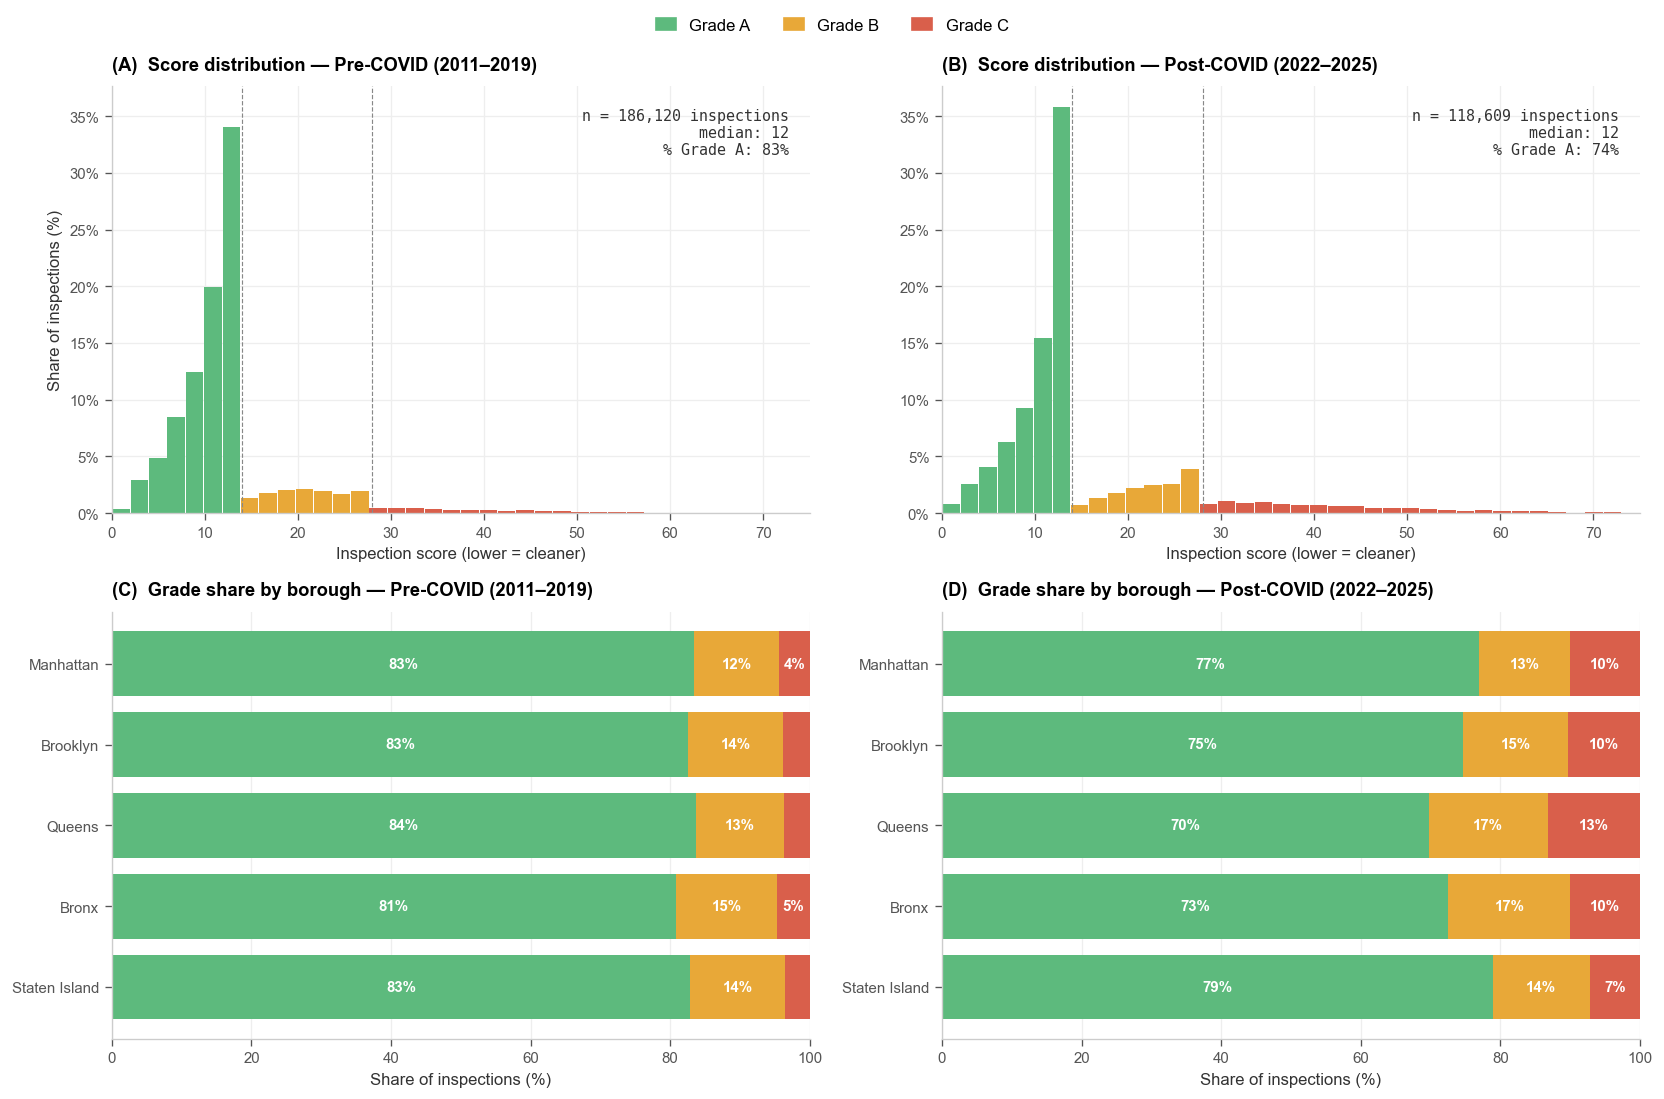

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Section 2.2 — Exploratory Data Analysis
# 2x2 panel: score distribution and borough grade share, pre- vs post-COVID
# Designed for high data-ink ratio: minimal chartjunk, direct labeling.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

GRADE_COLORS = {"A": "#5dba7d", "B": "#e8a838", "C": "#d95f4b"}
BORO_ORDER   = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
CLIP_X       = 75
N_BINS       = 38

def zone(x):
    return GRADE_COLORS["A"] if x < 14 else GRADE_COLORS["B"] if x < 28 else GRADE_COLORS["C"]

# ── Slice eras from the merged, COVID-pause-removed dataset ────────────────
pre  = df_merged_no_covid[df_merged_no_covid["PERIOD"] == "pre_covid"]
post = df_merged_no_covid[df_merged_no_covid["PERIOD"] == "post_covid"]

# ── Figure layout ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9.2))
(ax_a, ax_b), (ax_c, ax_d) = axes

edges     = np.linspace(0, CLIP_X, N_BINS + 1)
centers   = (edges[:-1] + edges[1:]) / 2
bin_w     = edges[1] - edges[0]
bar_cols  = [zone(c) for c in centers]

# ───────────────────────────────────────────────────────────────────────────
# (A) (B) Score distributions
# ───────────────────────────────────────────────────────────────────────────
def plot_scores(ax, era, panel_label, era_label):
    scores = era.loc[era["SCORE"].notna() & (era["SCORE"] <= CLIP_X), "SCORE"]
    counts, _ = np.histogram(scores, bins=edges)
    pct = counts / counts.sum() * 100

    ax.bar(centers, pct, width=bin_w * 0.95, color=bar_cols)
    ax.axvline(14, color="#888", linewidth=0.7, linestyle="--")
    ax.axvline(28, color="#888", linewidth=0.7, linestyle="--")

    median = scores.median()
    pct_a  = (scores < 14).mean() * 100
    ax.text(0.97, 0.95,
            f"n = {len(scores):,} inspections\n"
            f"median: {median:.0f}\n"
            f"% Grade A: {pct_a:.0f}%",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color="#333", family="monospace")

    ax.set_title(f"({panel_label})  Score distribution — {era_label}",
                 loc="left", fontweight="bold", fontsize=11)
    ax.set_xlabel("Inspection score (lower = cleaner)")
    ax.set_xlim(0, CLIP_X)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    for s in ["top", "right"]: ax.spines[s].set_visible(False)

plot_scores(ax_a, pre,  "A", "Pre-COVID (2011–2019)")
plot_scores(ax_b, post, "B", "Post-COVID (2022–2025)")

y_top = max(ax_a.get_ylim()[1], ax_b.get_ylim()[1])
ax_a.set_ylim(0, y_top)
ax_b.set_ylim(0, y_top)
ax_a.set_ylabel("Share of inspections (%)")


# ───────────────────────────────────────────────────────────────────────────
# (C) (D) Borough × grade share — no per-axes legend
# ───────────────────────────────────────────────────────────────────────────
def plot_boro(ax, era, panel_label, era_label):
    boro_pct = (era.groupby(["BORO", "GRADE"]).size()
                   .unstack(fill_value=0)
                   .reindex(BORO_ORDER)[["A","B","C"]])
    boro_pct = boro_pct.div(boro_pct.sum(axis=1), axis=0) * 100

    left = np.zeros(len(BORO_ORDER))
    for grade in ["A", "B", "C"]:
        ax.barh(BORO_ORDER, boro_pct[grade], left=left, color=GRADE_COLORS[grade])
        for i, v in enumerate(boro_pct[grade]):
            if v >= 4:
                ax.text(left[i] + v/2, i, f"{v:.0f}%", ha="center", va="center",
                        color="white", fontsize=9, fontweight="bold")
        left += boro_pct[grade].values

    ax.set_xlim(0, 100)
    ax.set_title(f"({panel_label})  Grade share by borough — {era_label}",
                 loc="left", fontweight="bold", fontsize=11)
    ax.set_xlabel("Share of inspections (%)")
    ax.invert_yaxis()
    for s in ["top", "right"]: ax.spines[s].set_visible(False)

plot_boro(ax_c, pre,  "C", "Pre-COVID (2011–2019)")
plot_boro(ax_d, post, "D", "Post-COVID (2022–2025)")

# ── Single figure-level legend in the top margin ───────────────────────────
handles = [plt.Rectangle((0, 0), 1, 1, color=GRADE_COLORS[g]) for g in ["A", "B", "C"]]
fig.legend(handles, ["Grade A", "Grade B", "Grade C"],
           loc="upper center", bbox_to_anchor=(0.5, 1.0),
           frameon=False, fontsize=10, ncol=3, handlelength=1.2,
           columnspacing=2.0)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave room for the legend
plt.show()

> **Figure 1:** Comparative Analysis of NYC Restaurant Inspection Outcomes (2011–2025).This two-by-two panel, derived from the df_merged_no_covid data frame, illustrates the shift in sanitary standards between the pre- and post-pandemic eras (2011–2019 and 2022–2025, respectively). Panels A and B show the distribution of inspection scores and reveal a significant "clustering" effect just below the Grade A threshold of 14 points, as well as a 9-percentage-point decline in Grade A attainment post-pandemic. Panels C and D disaggregate these results by borough. While Manhattan and Staten Island have remained relatively resilient, the Bronx and Queens have experienced the most significant increases in Grade B and C designations. The visualization has a high data-ink ratio. It uses direct percentage labeling and minimal grid interference to emphasize the downward trend in top-tier grades.

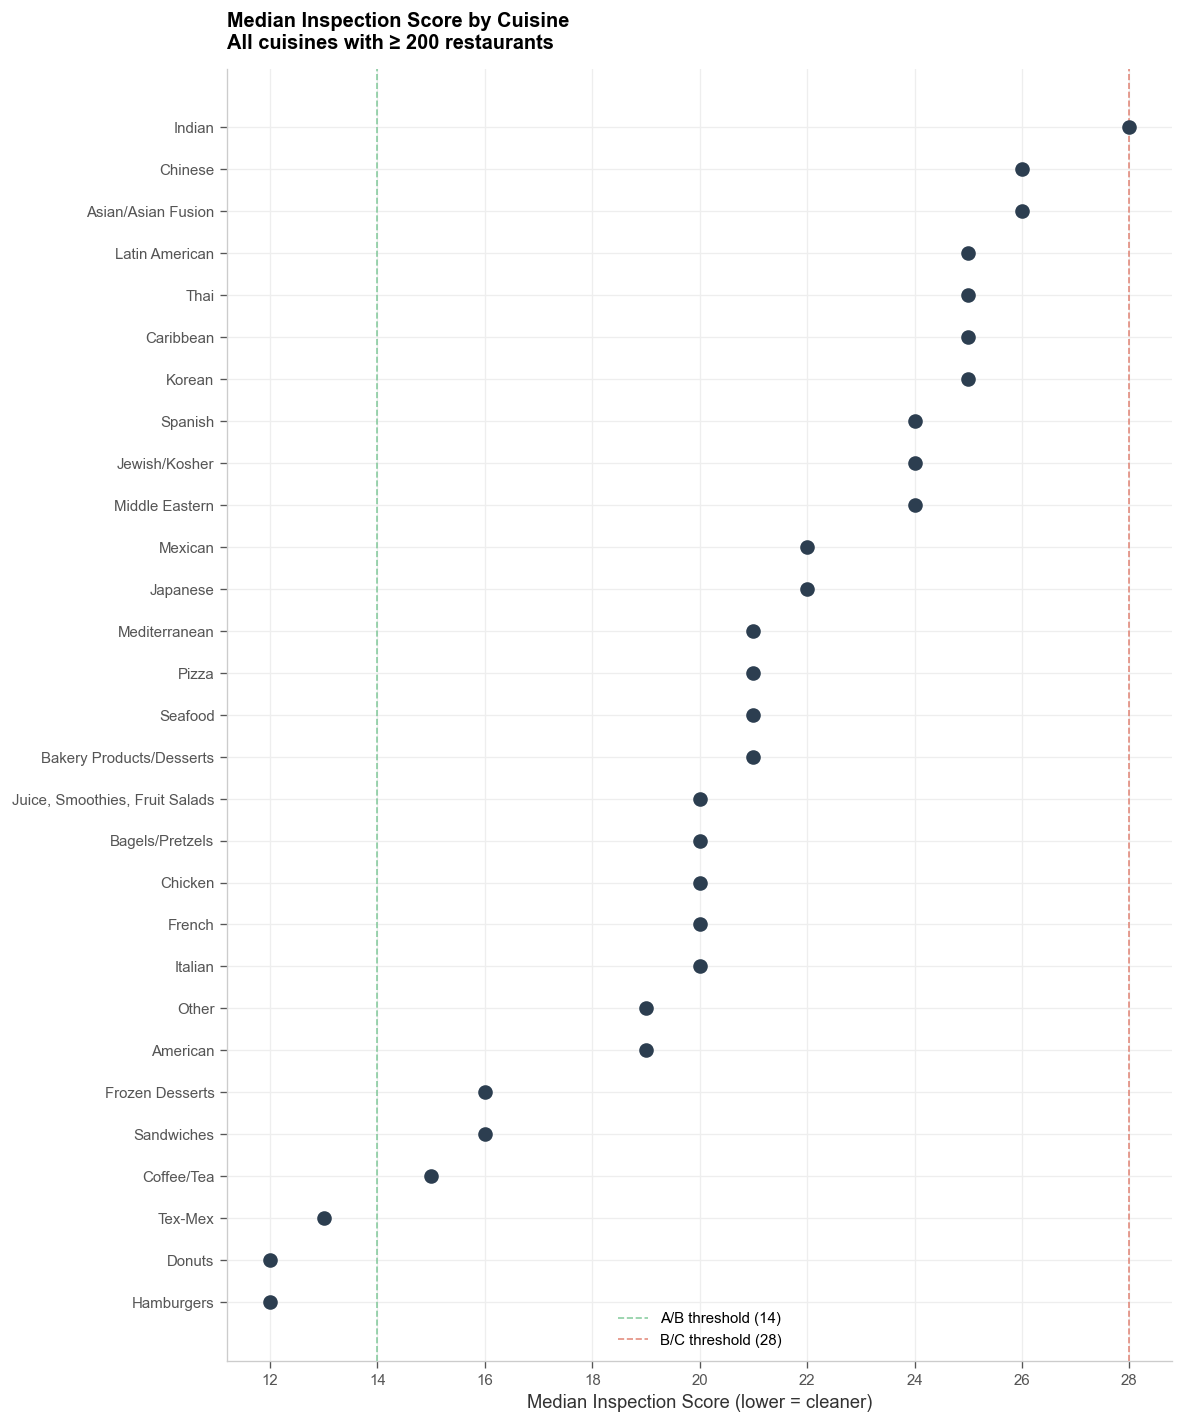

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Section 2.2 — Cuisine overview dot plot (no selection highlighted)
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import pandas as pd

# ── Use raw data for honest score distribution ──────────────────────────────
raw = df26_raw.copy()
raw["INSPECTION DATE"] = pd.to_datetime(raw["INSPECTION DATE"], errors="coerce")
raw = raw[raw["INSPECTION DATE"] != pd.Timestamp("1900-01-01")]
raw = raw[raw["BORO"] != "0"]
raw["SCORE"] = pd.to_numeric(raw["SCORE"], errors="coerce")
raw = raw.dropna(subset=["SCORE", "CUISINE DESCRIPTION"])
raw = raw[raw["SCORE"] >= 0]

# ── Build per-cuisine summary ───────────────────────────────────────────────
cuisine_summary = (raw
                   .groupby("CUISINE DESCRIPTION")
                   .agg(
                       n_restaurants=("CAMIS",  "nunique"),
                       median_score =("SCORE",  "median"),
                   )
                   .reset_index()
                   .query("n_restaurants >= 200")
                   .sort_values("median_score"))

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))

ax.scatter(
    cuisine_summary["median_score"],
    cuisine_summary["CUISINE DESCRIPTION"],
    color="#2c3e50",
    s=60,
    zorder=3
)

# Grade threshold lines
ax.axvline(14, color=GRADE_COLORS["A"], linewidth=1,
           linestyle="--", alpha=0.7, label="A/B threshold (14)")
ax.axvline(28, color=GRADE_COLORS["C"], linewidth=1,
           linestyle="--", alpha=0.7, label="B/C threshold (28)")

ax.legend(frameon=False, fontsize=9)
ax.set_xlabel("Median Inspection Score (lower = cleaner)", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Median Inspection Score by Cuisine\nAll cuisines with ≥ 200 restaurants",
    fontsize=12, fontweight="bold", loc="left", pad=12
)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
ax.grid(axis="x", color="#eeeeee", linewidth=0.8)

plt.tight_layout()
plt.savefig("eda_cuisine_overview.png", dpi=150, bbox_inches="tight")
plt.show()

> **Figure 2:** Systematic Comparison of Sanitary Compliance by Cuisine . This visualization uses the df26_raw data frame to rank the most prevalent New York City (NYC) cuisines (N ≥ 200) by median inspection score. The data underwent rigorous cleaning to ensure accuracy, including the removal of invalid dates (e.g., January 1, 1900) and unmapped boroughs. The resulting dot plot clearly shows that standardized food models, such as hamburgers and doughnuts, comfortably achieve median scores within the Grade A range ($14 or less). In contrast, many diverse international cuisines, including Indian, Chinese, and Latin American, tend to fall within the Grade B range ($14–$28). These results suggest that regulatory "cleanliness" is not evenly distributed across different cooking styles.

In [6]:
SELECTED_CUISINES = [
    "Chinese", "Mexican", "Indian", "Middle Eastern",                # often distrusted / casual
    "Italian", "American", "Mediterranean", "Jewish/Kosher",  # often trusted / upscale
]

---
## 3 Data Analysis



### 3.1 — Inspection Score Distribution by Cuisine (Box Plot + Raincloud)

We use the variable df_2026_no_covid, based on each restaurant's most recent gradable inspection, to compare score distributions across eight cuisines spanning the full trust spectrum. These cuisines range from the culturally familiar, such as American, Italian, and Mediterranean, to the frequently stereotyped, such as Chinese, Indian, Middle Eastern, Mexican, and Jewish/kosher. The side-by-side boxplot and raincloud plot show that the median scores are tightly clustered between 10 and 14 points, squarely at the A/B boundary, for all groups. The interquartile ranges substantially overlap, and the kernel density plot confirms that the most common outcome for every cuisine type is a score in the A range. Chinese and Indian restaurants show slightly wider distributions and longer right tails. However, the difference in medians amounts to less than one additional violation, which is far smaller than consumer stereotypes would predict. This is the first quantitative rebuttal to the bias introduced by the website in Act 1. Readers distrust the cuisines they perceive as dirty the most. However, they are not meaningfully dirtier than the cuisines they trust, as measured by official health inspectors.

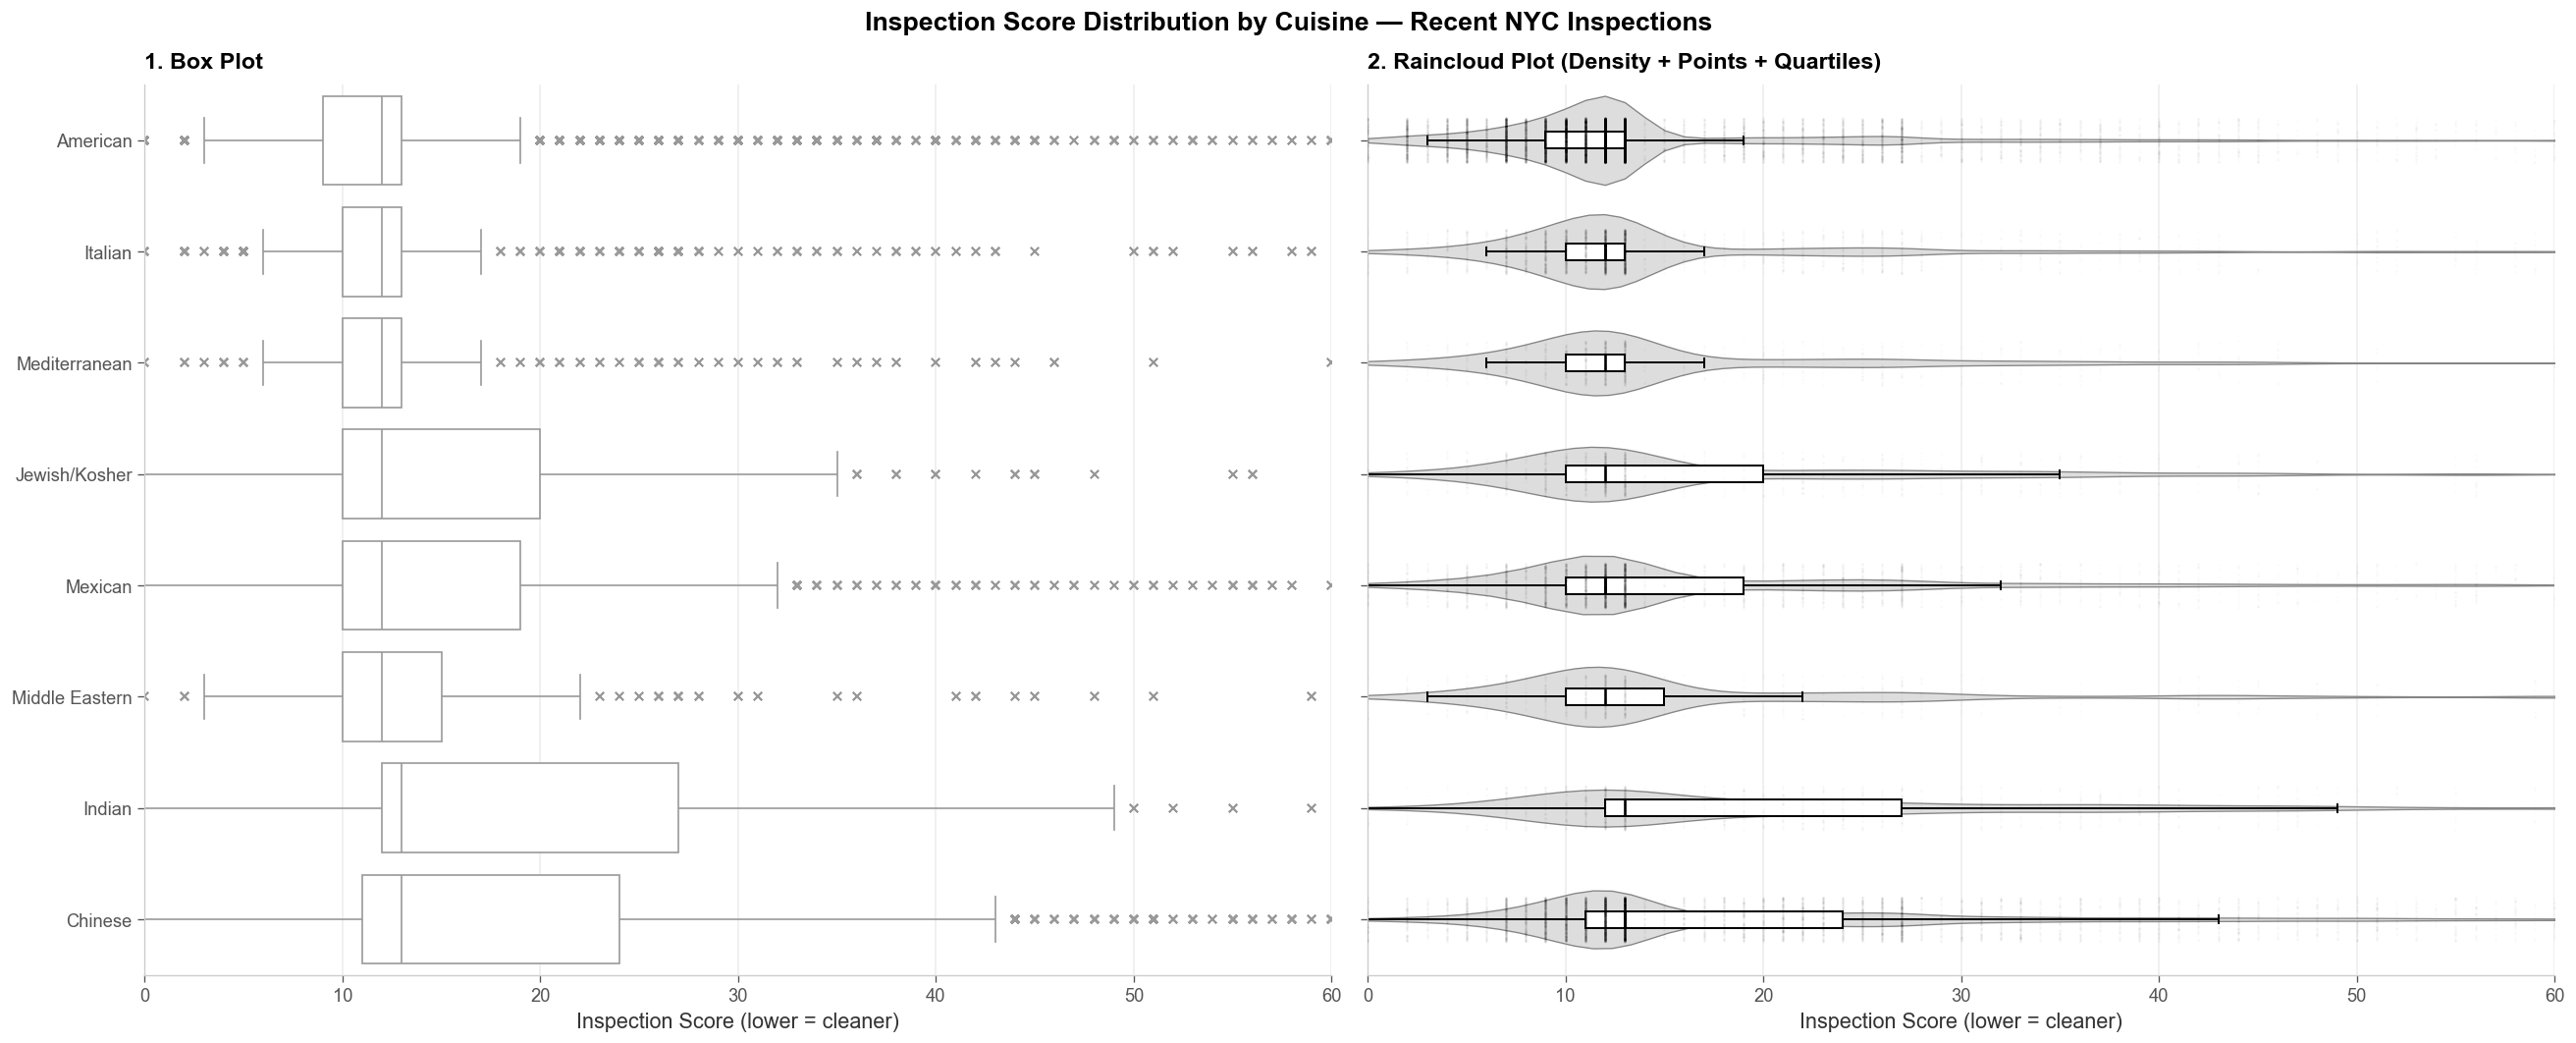

In [7]:
# Part W1 — Box plots of inspection score distribution by cuisine (subplot: Box Plot + Raincloud Plot)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Prepare data ---------------------------------------------------------
# Assumes `df` is already loaded and cleaned (gradable inspections, post-2010, valid grades)

# Keep only rows with a numeric score and a cuisine
df_plot = df_2026_no_covid.dropna(subset=['SCORE', 'CUISINE DESCRIPTION']).copy()
df_plot['SCORE'] = pd.to_numeric(df_plot['SCORE'], errors='coerce')
df_plot = df_plot.dropna(subset=['SCORE'])
df_plot = df_plot[df_plot['SCORE'] >= 0]
df_plot = df_plot[df_plot['CUISINE DESCRIPTION'].isin(SELECTED_CUISINES)]

# Sort cuisines alphabetically (same convention as reference plot)
cuisine_categories = (df_plot.groupby('CUISINE DESCRIPTION')['SCORE']
                             .median()
                             .sort_values()
                             .index.tolist())

# --- 2. Create 1x2 subplot ---------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9), sharey=True)
fig.suptitle('Inspection Score Distribution by Cuisine — Recent NYC Inspections',
             fontsize=16, y=0.98, fontweight='bold')

# ═══════════════════════════════════════════════════════════════════
# LEFT PLOT: Box Plot (Classic)
# ═══════════════════════════════════════════════════════════════════
sns.boxplot(
    data=df_plot,
    x='SCORE',
    y='CUISINE DESCRIPTION',
    order=cuisine_categories,
    ax=ax1,
    color='white',
    flierprops={'marker': 'x', 'markersize': 5, 'alpha': 1}
)

ax1.set_ylabel('', fontsize=12)
ax1.set_xlabel('Inspection Score (lower = cleaner)', fontsize=13)
ax1.set_title('1. Box Plot', fontsize=14, fontweight='bold', loc='left', pad=10)
ax1.set_xlim(0, 60)
ax1.set_xticks(range(0, 61, 10))
ax1.set_xticklabels([str(s) for s in range(0, 61, 10)], fontsize=11)
ax1.tick_params(axis='y', labelsize=11)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')
ax1.grid(axis='x', color='#eeeeee', linestyle='-', linewidth=1)

# ═══════════════════════════════════════════════════════════════════
# RIGHT PLOT: Raincloud Plot (Violin + Strip + Box)
# ═══════════════════════════════════════════════════════════════════

# 1. Half violin plot (density)
sns.violinplot(
    data=df_plot,
    x='SCORE',
    y='CUISINE DESCRIPTION',
    order=cuisine_categories,
    ax=ax2,
    color='#dddddd',
    inner=None,
    cut=0,
    linewidth=0.8
)

# 2. Strip plot (individual data points with very low alpha for large dataset)
sns.stripplot(
    data=df_plot,
    x='SCORE',
    y='CUISINE DESCRIPTION',
    order=cuisine_categories,
    ax=ax2,
    color='black',
    alpha=0.015,   # Very low alpha due to large dataset
    size=1.5,
    jitter=0.2
)

# 3. Overlay narrow box plot for quartiles
sns.boxplot(
    data=df_plot,
    x='SCORE',
    y='CUISINE DESCRIPTION',
    order=cuisine_categories,
    ax=ax2,
    width=0.15,
    color='white',
    showfliers=False,   # Don't duplicate outliers
    boxprops=dict(edgecolor='black', linewidth=1.2),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    medianprops=dict(color='black', linewidth=1.5)
)

ax2.set_ylabel('', fontsize=12)
ax2.set_xlabel('Inspection Score (lower = cleaner)', fontsize=13)
ax2.set_title('2. Raincloud Plot (Density + Points + Quartiles)',
              fontsize=14, fontweight='bold', loc='left', pad=10)
ax2.set_xlim(0, 60)
ax2.set_xticks(range(0, 61, 10))
ax2.set_xticklabels([str(s) for s in range(0, 61, 10)], fontsize=11)
ax2.tick_params(axis='y', labelsize=11)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')
ax2.grid(axis='x', color='#eeeeee', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

> **Figure 3:** Comparative distribution of NYC sanitary inspection scores across eight major cuisine categories. (1) Box Plot: Visualizes the median, interquartile range (IQR), and outlier frequency ($k > 1.5 \times \text{IQR}$) for each category. (2) Raincloud Plot: Provides a synchronized view of kernel density estimates (KDE), raw data points, and quartiles. Despite cultural stereotypes, median scores remain tightly clustered within the $12 \pm 2$ range. While Chinese and Indian categories exhibit higher variance and extended right tails (indicating a higher frequency of high-score outliers), the primary density for all groups is concentrated below the 14-point "Grade A" threshold, suggesting statistical parity in median cleanliness across the trust spectrum.

### 3.2  — Cuisine Violation Benchmarks (Cleveland Dot Plot)

We grouped each restaurant's violations into the following five categories using the "df_2026_no_covid" dataset:
Personal Hygiene and Food Protection (06A–06H); Handling Protocols (04A–04P, 05A–05H, 04K–04O, 08A–08C, and 28-06); Pest Control and Sanitation (02A–02I, 03A–03G, 04K–04O, 08A–08C, and 28-06); Thermal Safety (02A–02I, 03A–03G, 04K–04O, and 08A–08C); and Infrastructure and Maintenance (07A, 09A–09E, 10A–10J, and 28-07).

Then, we calculated the number of violations per 100 restaurants for each of the eight selected cuisines. The Cleveland dot plot fixes the vertical order by total violations across all categories, enabling readers to track each cuisine horizontally instead of re-reading a new ranking in every panel.
The numbers tell a story that challenges the stereotype. Chinese and Indian restaurants scored highest in pest control (134.7 and 140.6, respectively), the category most associated with a "dirty kitchen." However, their personal hygiene scores are virtually identical to those of American and Italian restaurants (100.5 and 97.7 versus 97.8 and 99.7, respectively).
Every cuisine dominated infrastructure and maintenance, with scores ranging from 163.9 to 186.5 violations per 100 restaurants. These results suggest that the main cause of citywide violations is structural and involves drains, ventilation, and lighting rather than food handling practices, which are often the target of consumer stereotypes.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cleveland Dot Plot — Cuisine Violation Benchmarks
# Uses df_2026_no_covid; violations grouped into 5 functional categories
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── 1. Category → violation code mapping (DOHMH blue book) ─────────────────
CATEGORY_MAP = {
    "Personal Hygiene & Food Protection": [
        "06A",  # Personal cleanliness inadequate
        "06B",  # Tobacco/eating in food prep area
        "06C",  # Food not protected from contamination
        "06D",  # Food contact surface not sanitized
        "06E",  # Sanitized utensil improperly stored
        "06F",  # Wiping cloths improperly stored
        "06G",  # HACCP plan not approved
        "06H",  # HACCP records not maintained
    ],
    "Handling Protocols": [
        "04A",  # Food Protection Certificate not held
        "04B",  # Food worker working while sick
        "04C",  # Bare hand contact with food
        "04D",  # Handwashing after toilet/coughing
        "04E",  # Toxic chemical improperly stored
        "04F",  # Food prep area contaminated
        "04H",  # Food adulterated/cross-contaminated
        "04I",  # Non-TCS food re-served
        "04J",  # Thermometer not provided
        "04P",  # Food containing prohibited substance
        "05A",  # Sewage disposal improper
        "05B",  # Harmful gas/CO detected
        "05C",  # Food contact surface improperly constructed
        "05D",  # No hand washing facility
        "05E",  # Toilet facility not provided
        "05F",  # Insufficient cold/hot holding equipment
        "05H",  # No SOP for refillable containers
        "09E",  # Wash hands sign not posted
        "03I",  # Juice packaged on premises, no label
        "28-05", # Food adulterated or misbranded
    ],
    "Pest Control & Sanitation": [
        "04K",  # Evidence of rats
        "04L",  # Evidence of mice
        "04M",  # Live roaches
        "04N",  # Filth flies or nuisance pests
        "04O",  # Live animal other than fish
        "08A",  # Harborage conditions for rodents/insects
        "08B",  # Garbage receptacle not pest resistant
        "08C",  # Pesticide improperly used
        "28-06", # No pest management contract on premises
    ],
    "Thermal Safety": [
        "02A",  # TCS food not cooked to minimum temp
        "02B",  # Hot food not held at/above 140°F
        "02C",  # Cooked food not reheated before service
        "02D",  # Pre-cooked TCS not held at proper temp
        "02F",  # Raw meat/fish served undercooked
        "02G",  # Cold TCS food held above 41°F
        "02H",  # TCS food not cooled by approved method
        "02I",  # TCS food not cooled from 140°F to 70°F
        "03A",  # Food from unapproved source
        "03B",  # Shellfish not from approved source
        "03C",  # Unclean/cracked eggs kept or used
        "03D",  # Food package not in good condition
        "03E",  # No potable water supply
        "03F",  # Unpasteurized milk served
        "03G",  # Raw fruit/vegetable not properly washed
    ],
    "Infrastructure & Maintenance": [
        "07A",  # Officer duties obstructed
        "09A",  # Damaged canned food not segregated
        "09B",  # Thawing procedure improper
        "09C",  # Food contact surface not maintained
        "09D",  # Food operation in living/sleeping quarters
        "10A",  # Toilet facility not maintained
        "10B",  # Anti-siphonage device not provided
        "10C",  # Lighting inadequate
        "10D",  # Ventilation not provided/inadequate
        "10E",  # Accurate thermometer not in fridge
        "10F",  # Non-food contact surface unacceptable
        "10G",  # Dishwashing/ware washing improper
        "10H",  # Proper sanitization not provided
        "10I",  # Single service item reused
        "10J",  # Hand wash sign not posted
        "28-07", # Unapproved outdoor/sidewalk cooking
    ],
}
RAW_COLS = list(CATEGORY_MAP.keys())

SELECTED_CUISINES = [
    "American", "Italian", "Mediterranean", "Jewish/Kosher",
    "Mexican", "Middle Eastern", "Indian", "Chinese",
]

# ── 2. Reverse lookup: violation code → category ────────────────────────────
code_to_cat = {
    code: cat
    for cat, codes in CATEGORY_MAP.items()
    for code in codes
}

# ── 3. Filter & tag violations ──────────────────────────────────────────────
df_viol = df_2026_no_covid.copy()
df_viol = df_viol[df_viol["CUISINE DESCRIPTION"].isin(SELECTED_CUISINES)]
df_viol = df_viol.dropna(subset=["VIOLATION CODE", "CAMIS"])
df_viol["VIOLATION CODE"] = df_viol["VIOLATION CODE"].str.strip()
df_viol["CATEGORY"] = df_viol["VIOLATION CODE"].map(code_to_cat)
df_viol = df_viol.dropna(subset=["CATEGORY"])

# ── 4. Violations per 100 restaurants ───────────────────────────────────────
n_restaurants = (
    df_2026_no_covid[df_2026_no_covid["CUISINE DESCRIPTION"].isin(SELECTED_CUISINES)]
    .groupby("CUISINE DESCRIPTION")["CAMIS"]
    .nunique()
)

viol_counts = (
    df_viol.groupby(["CUISINE DESCRIPTION", "CATEGORY"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=RAW_COLS, fill_value=0)
)

cleveland_df = viol_counts.div(n_restaurants, axis=0).mul(100).reset_index()
cleveland_df.columns.name = None

print("Violations per 100 restaurants:")
print(cleveland_df.set_index("CUISINE DESCRIPTION").round(1))

# ── Fix: consistent cuisine order across all panels ──────────────────────────
cuisine_order = (
    cleveland_df.set_index("CUISINE DESCRIPTION")[RAW_COLS]
    .sum(axis=1)
    .sort_values(ascending=True)  # worst at top
    .index.tolist()
)

# ── Plot config ───────────────────────────────────────────────────────────────
TITLE_COLOR = "#000000"
SUB_COLOR   = "#666666"
TEXT_COLOR  = "#333333"
DOT_COLOR   = "#444444"
LINE_COLOR  = "#EAEAEA"

n_cuisines = len(cuisine_order)
n_cat      = len(RAW_COLS)

x_max = cleveland_df[RAW_COLS].values.max()
x_pad = x_max * 0.15

fig = make_subplots(
    rows=1,
    cols=n_cat,
    shared_yaxes=False,
    horizontal_spacing=0.04,
)

for i, col in enumerate(RAW_COLS):
    col_num = i + 1

    # FIXED ORDER — same y position for every cuisine in every panel
    sub      = cleveland_df.set_index("CUISINE DESCRIPTION").reindex(cuisine_order)[col]
    cuisines = cuisine_order
    values   = sub.values
    y_pos    = list(range(len(cuisines)))

    # Hairline tracks
    for y, v in zip(y_pos, values):
        fig.add_shape(
            type="line",
            x0=0, x1=v, y0=y, y1=y,
            line=dict(color=LINE_COLOR, width=0.8),
            row=1, col=col_num,
        )

    # Dots
    fig.add_trace(
        go.Scatter(
            x=values,
            y=y_pos,
            mode="markers",
            marker=dict(
                size=8,
                color=DOT_COLOR,
                line=dict(color="white", width=1.5),
            ),
            customdata=list(zip(cuisines, [round(float(v), 1) for v in values])),
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                + col + ": <b>%{customdata[1]:.1f}</b> per 100 restaurants"
                + "<extra></extra>"
            ),
            showlegend=False,
        ),
        row=1, col=col_num,
    )

    # Axis config
    xaxis_key = "xaxis" if col_num == 1 else f"xaxis{col_num}"
    yaxis_key = "yaxis" if col_num == 1 else f"yaxis{col_num}"

    fig.update_layout(**{
        xaxis_key: dict(
            range=[-x_pad * 0.05, x_max + x_pad * 0.8],
            showgrid=False,
            zeroline=False,
            tickfont=dict(size=8, color=SUB_COLOR),
            showline=True,
            linecolor=LINE_COLOR,
            linewidth=1,
            ticks="outside",
            ticklen=0,
        ),
        yaxis_key: dict(
            tickvals=y_pos,
            ticktext=cuisines if i == 0 else [""] * len(cuisines),
            range=[-0.8, n_cuisines - 0.2],
            showgrid=False,
            zeroline=False,
            tickfont=dict(size=9, color=TEXT_COLOR),
            showline=False,
            ticks="",
        ),
    })

    # Panel title
    fig.add_annotation(
        text=f"<b>{col}</b>",
        xref=f"x{col_num if col_num > 1 else ''} domain",
        yref=f"y{col_num if col_num > 1 else ''} domain",
        x=0,
        y=1.08,
        showarrow=False,
        font=dict(size=10, color=TITLE_COLOR),
        xanchor="left",
        yanchor="bottom",
    )

# ── Figure-level layout ───────────────────────────────────────────────────────
panel_w = 2.4 * n_cat + 1.2
panel_h = 0.35 * n_cuisines + 1.8

fig.update_layout(
    width=int(panel_w * 96),
    height=int(panel_h * 96),
    paper_bgcolor="white",
    plot_bgcolor="white",
    title=dict(
        text="<b>Cuisine Violation Benchmarks</b>",
        x=0.01,
        xanchor="left",
        y=0.98,
        yanchor="top",
        font=dict(size=16, color=TITLE_COLOR),
    ),
    margin=dict(l=10, r=20, t=80, b=50),
    hoverlabel=dict(
        bgcolor="white",
        bordercolor=DOT_COLOR,
        font=dict(size=11, color=TEXT_COLOR),
    ),
)

fig.add_annotation(
    text="<b>Violations per 100 restaurants</b>",
    xref="paper", yref="paper",
    x=0.5, y=-0.1,
    showarrow=False,
    font=dict(size=9, color=SUB_COLOR),
    xanchor="center",
)

fig.show()

Violations per 100 restaurants:
                     Personal Hygiene & Food Protection  Handling Protocols  \
CUISINE DESCRIPTION                                                           
American                                           97.8                38.7   
Chinese                                           100.5                26.2   
Indian                                             97.7                42.5   
Italian                                            99.7                29.6   
Jewish/Kosher                                     102.7                41.3   
Mediterranean                                      98.2                33.9   
Mexican                                            96.4                35.6   
Middle Eastern                                     67.0                46.0   

                     Pest Control & Sanitation  Thermal Safety  \
CUISINE DESCRIPTION                                              
American                                  98.

> **Figure 4:** This is a benchmark of categorical violations across eight types of cuisine, normalized to 100 restaurants. To enable direct cross-category comparisons, this faceted Cleveland dot plot uses fixed vertical sorting based on total cumulative violations. Violations are grouped into five regulatory categories, ranging from behavioral (e.g., personal hygiene, 06A–06H) to structural (e.g., infrastructure and maintenance, 07A–2807). The visualization shows that infrastructure and maintenance serve as the citywide baseline for noncompliance, with all cuisines clustering between 163.9 and 186.5 violations. While pest control scores show higher variance among Chinese and Indian cuisines, the personal hygiene domain exhibits remarkable parity across the trust spectrum. This suggests that behavioral safety standards are consistent regardless of cuisine category.

### 3.3 — Logistic Regression: Can Cuisine Predict Grade A? (ML)

We used the `df_2026_no_covid` dataset to train a logistic regression model that predicts whether a restaurant will receive a grade A (score <14) on its most recent gradable inspection. We compared three feature sets—cuisine type only, borough only, and cuisine and borough combined—against a naïve baseline that always predicts the majority class. Using 5-fold cross-validation, all three models achieved an accuracy of 86.9%, identical to the baseline. These results suggest that knowing a restaurant's cuisine type or borough does not provide additional predictive value beyond randomly guessing "Grade A." The coefficient panel reinforces this finding. All cuisine coefficients are negative relative to American cuisine and small in magnitude. This indicates that the model detects no positive correlation between any stereotyped cuisine and a higher likelihood of failing. In fact, Indian and Chinese restaurants are associated with slightly lower odds of receiving a non-A grade once the model is fit. This is the opposite of what consumer bias would predict. Despite being trained purely on inspection outcomes, the machine cannot identify the pattern that stereotypes suggest is present.

Total restaurants : 9,292
Grade A           : 8,076  (86.9%)
Grade B/C         : 1,216  (13.1%)


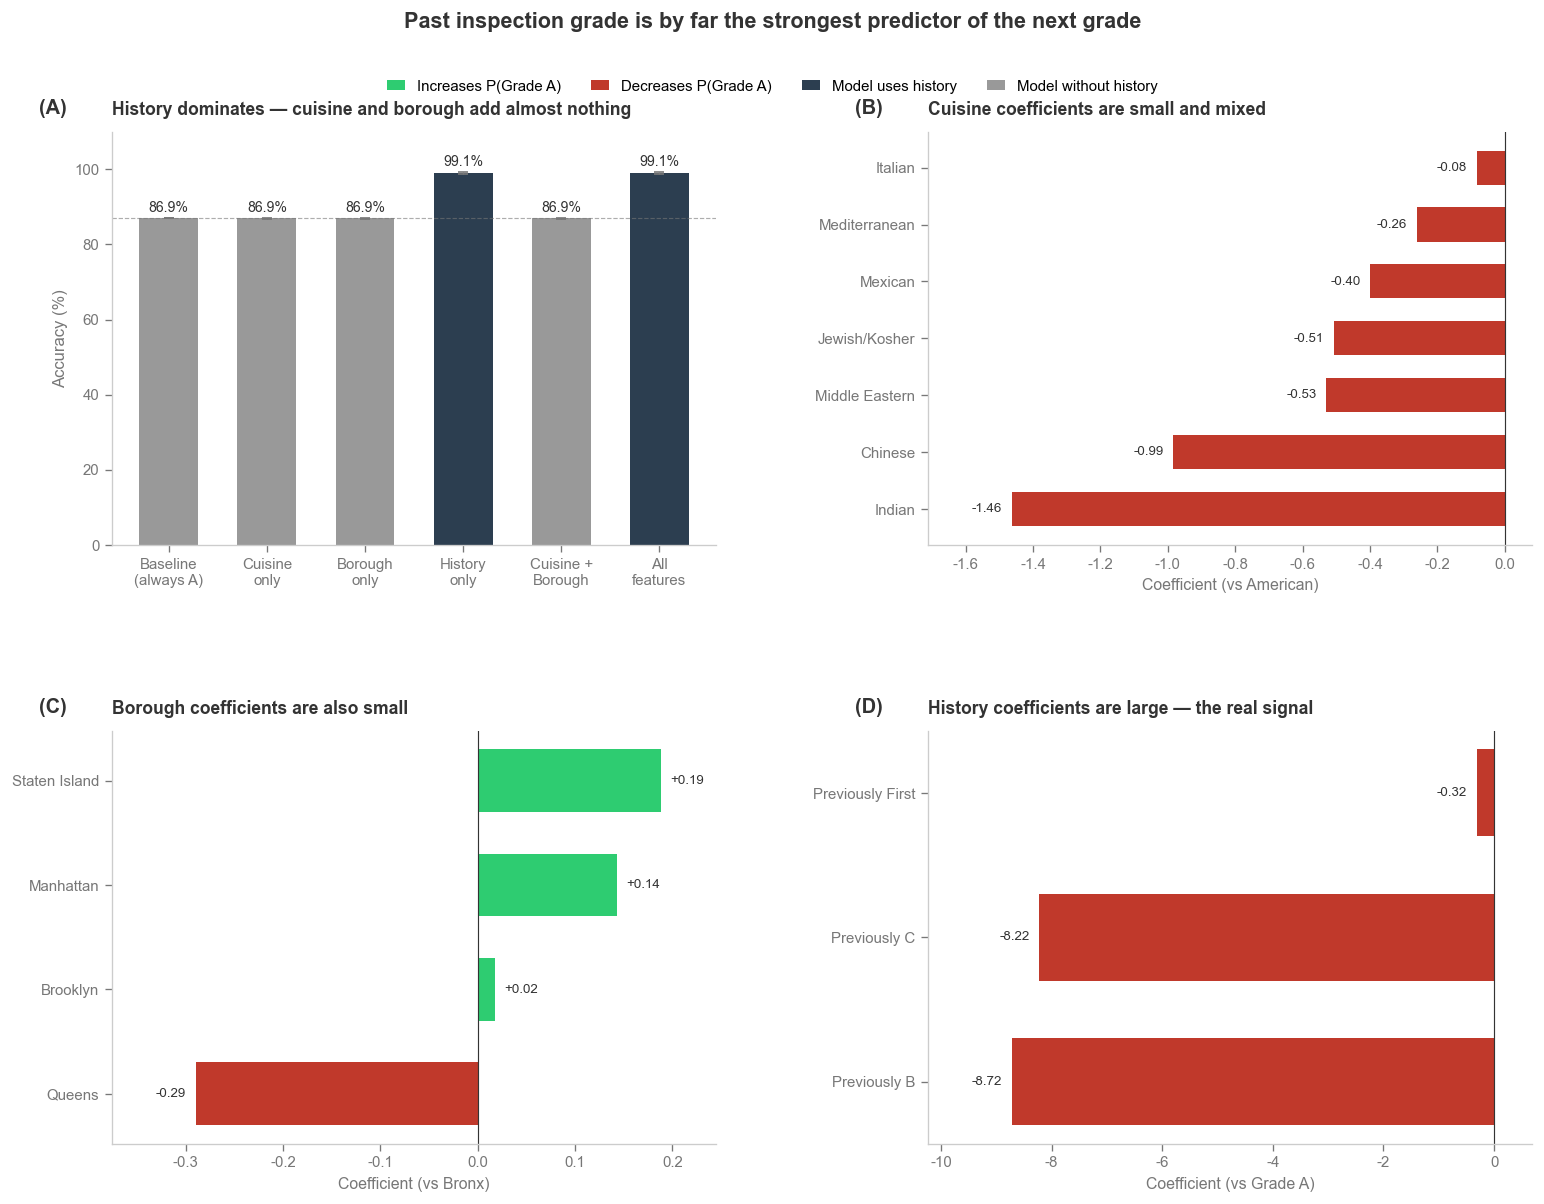

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# ML — Logistic Regression: Can cuisine / borough / history predict Grade A?
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from matplotlib.patches import Patch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")

SELECTED_CUISINES = [
    "American", "Italian", "Mediterranean", "Jewish/Kosher",
    "Mexican", "Middle Eastern", "Indian", "Chinese",
]

# ── 1. Build modeling dataframe ──────────────────────────────────────────────
df = df_2026_no_covid.copy()
df = df[df["CUISINE DESCRIPTION"].isin(SELECTED_CUISINES)]
df["SCORE"]           = pd.to_numeric(df["SCORE"], errors="coerce")
df["INSPECTION DATE"] = pd.to_datetime(df["INSPECTION DATE"])
df = df.dropna(subset=["SCORE", "CAMIS", "CUISINE DESCRIPTION", "BORO"])
df = df.sort_values(["CAMIS", "INSPECTION DATE"])

def get_prev_grade(group):
    group = group.copy()
    group["prev_grade"] = group["GRADE"].shift(1)
    return group

df = df.groupby("CAMIS", group_keys=False).apply(get_prev_grade)
df_latest = df.drop_duplicates(subset=["CAMIS"], keep="last").copy()
df_latest["grade_A"] = (df_latest["SCORE"] < 14).astype(int)
df_latest["prev_grade"] = df_latest["prev_grade"].fillna("First")
df_latest = df_latest[df_latest["prev_grade"].isin(["A", "B", "C", "First"])]

print(f"Total restaurants : {len(df_latest):,}")
print(f"Grade A           : {df_latest['grade_A'].sum():,}  "
      f"({df_latest['grade_A'].mean()*100:.1f}%)")
print(f"Grade B/C         : {(df_latest['grade_A']==0).sum():,}  "
      f"({(df_latest['grade_A']==0).mean()*100:.1f}%)")

# ── 2. Encode features ───────────────────────────────────────────────────────
df_model = df_latest[[
    "grade_A", "CUISINE DESCRIPTION", "BORO", "prev_grade"
]].copy()
df_model = pd.get_dummies(
    df_model,
    columns=["CUISINE DESCRIPTION", "BORO", "prev_grade"],
    drop_first=True
)

cuisine_cols = [c for c in df_model.columns if c.startswith("CUISINE")]
boro_cols    = [c for c in df_model.columns if c.startswith("BORO")]
history_cols = [c for c in df_model.columns if c.startswith("prev_grade")]

X_cuisine = df_model[cuisine_cols]
X_boro    = df_model[boro_cols]
X_history = df_model[history_cols]
X_both    = df_model[cuisine_cols + boro_cols]
X_all     = df_model[cuisine_cols + boro_cols + history_cols]
y         = df_model["grade_A"]

# ── 3. Cross-validated accuracy ──────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
scores_baseline = y.mean()
scores_cuisine  = cross_val_score(lr, X_cuisine, y, cv=5, scoring="accuracy")
scores_boro     = cross_val_score(lr, X_boro,    y, cv=5, scoring="accuracy")
scores_history  = cross_val_score(lr, X_history, y, cv=5, scoring="accuracy")
scores_both     = cross_val_score(lr, X_both,    y, cv=5, scoring="accuracy")
scores_all      = cross_val_score(lr, X_all,     y, cv=5, scoring="accuracy")

# ── 4. Fit individual models and extract coefficients ────────────────────────
lr.fit(X_cuisine, y)
coef_cuisine = pd.DataFrame({
    "feature"     : [c.replace("CUISINE DESCRIPTION_", "") for c in cuisine_cols],
    "coefficient" : lr.coef_[0],
}).sort_values("coefficient")

lr.fit(X_boro, y)
coef_boro = pd.DataFrame({
    "feature"     : [c.replace("BORO_", "") for c in boro_cols],
    "coefficient" : lr.coef_[0],
}).sort_values("coefficient")

lr.fit(X_history, y)
coef_history = pd.DataFrame({
    "feature"     : [c.replace("prev_grade_", "Previously ") for c in history_cols],
    "coefficient" : lr.coef_[0],
}).sort_values("coefficient")

# ── 5. PLOT ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.patch.set_facecolor("white")
ax_acc, ax_cuisine, ax_boro, ax_history = (
    axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]
)

COLOR_NEG       = "#c0392b"
COLOR_POS       = "#2ecc71"
COLOR_BAR       = "#999999"
COLOR_HIGHLIGHT = "#2c3e50"
COLOR_TEXT      = "#333333"
COLOR_MUTED     = "#777777"
COLOR_SPINE     = "#cccccc"
COLOR_GRID      = "#eeeeee"

def style_axis(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(COLOR_SPINE)
    ax.spines["bottom"].set_color(COLOR_SPINE)
    ax.tick_params(colors=COLOR_MUTED, labelsize=9)
    ax.set_axisbelow(True)

# ─── Panel A ─────────────────────────────────────────────────────────────────
model_labels = [
    "Baseline\n(always A)", "Cuisine\nonly", "Borough\nonly",
    "History\nonly", "Cuisine +\nBorough", "All\nfeatures",
]
accuracies = [
    scores_baseline       * 100,
    scores_cuisine.mean() * 100,
    scores_boro.mean()    * 100,
    scores_history.mean() * 100,
    scores_both.mean()    * 100,
    scores_all.mean()     * 100,
]
errors = [0,
          scores_cuisine.std() * 100, scores_boro.std()    * 100,
          scores_history.std() * 100, scores_both.std()    * 100,
          scores_all.std()     * 100]
bar_colors = [COLOR_BAR, COLOR_BAR, COLOR_BAR,
              COLOR_HIGHLIGHT, COLOR_BAR, COLOR_HIGHLIGHT]

bars = ax_acc.bar(model_labels, accuracies, color=bar_colors, width=0.6,
                  yerr=errors, capsize=3,
                  error_kw=dict(elinewidth=0.8, ecolor=COLOR_MUTED))
for bar, val in zip(bars, accuracies):
    ax_acc.text(bar.get_x() + bar.get_width()/2, val + 1,
                f"{val:.1f}%", ha="center", va="bottom",
                fontsize=8.5, color=COLOR_TEXT)
ax_acc.axhline(scores_baseline * 100, color=COLOR_MUTED,
               linewidth=0.7, linestyle="--", alpha=0.6)

ax_acc.set_ylim(0, 110)
ax_acc.set_ylabel("Accuracy (%)", fontsize=10, color=COLOR_MUTED)
ax_acc.yaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
ax_acc.set_title("History dominates — cuisine and borough add almost nothing",
                 fontsize=10.5, fontweight="bold", loc="left", pad=10, color=COLOR_TEXT)
ax_acc.grid(False)
ax_acc.tick_params(axis="x", labelsize=8.5)
style_axis(ax_acc)

# ─── Coefficient helper — with label-collision fix ───────────────────────────
def plot_coef(ax, coef_df, title, baseline_label):
    colors = [COLOR_NEG if v < 0 else COLOR_POS for v in coef_df["coefficient"]]
    ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors, height=0.6)
    ax.axvline(0, color=COLOR_TEXT, linewidth=0.7)

    vmin, vmax = coef_df["coefficient"].min(), coef_df["coefficient"].max()
    xrange = vmax - vmin if vmax != vmin else abs(vmax) or 1
    pad = xrange * 0.02

    # Expand x-limits so end-of-bar labels never collide with axis labels
    ax.set_xlim(vmin - xrange * 0.18, vmax + xrange * 0.12)

    for i, val in enumerate(coef_df["coefficient"]):
        ax.text(val + (pad if val >= 0 else -pad), i,
                f"{val:+.2f}",
                va="center", ha="left" if val >= 0 else "right",
                fontsize=8, color=COLOR_TEXT)

    ax.set_xlabel(f"Coefficient (vs {baseline_label})",
                  fontsize=9.5, color=COLOR_MUTED)
    ax.set_title(title, fontsize=10.5, fontweight="bold",
                 loc="left", pad=10, color=COLOR_TEXT)
    ax.grid(False)
    style_axis(ax)

plot_coef(ax_cuisine, coef_cuisine,
          "Cuisine coefficients are small and mixed", "American")
plot_coef(ax_boro, coef_boro,
          "Borough coefficients are also small", "Bronx")
plot_coef(ax_history, coef_history,
          "History coefficients are large — the real signal", "Grade A")

# ─── Panel labels ────────────────────────────────────────────────────────────
for label, ax in [("(A)", ax_acc), ("(B)", ax_cuisine),
                  ("(C)", ax_boro), ("(D)", ax_history)]:
    ax.text(-0.12, 1.08, label, transform=ax.transAxes,
            fontsize=12, fontweight="bold",
            color=COLOR_TEXT, ha="left", va="top")

# ─── Suptitle ────────────────────────────────────────────────────────────────
plt.suptitle("Past inspection grade is by far the strongest predictor of the next grade",
             fontsize=13, fontweight="bold", y=1.00, color=COLOR_TEXT)

# ─── Single figure-level legend ──────────────────────────────────────────────
legend_handles = [
    Patch(facecolor=COLOR_POS,       label="Increases P(Grade A)"),
    Patch(facecolor=COLOR_NEG,       label="Decreases P(Grade A)"),
    Patch(facecolor=COLOR_HIGHLIGHT, label="Model uses history"),
    Patch(facecolor=COLOR_BAR,       label="Model without history"),
]
fig.legend(handles=legend_handles,
           loc="upper center", bbox_to_anchor=(0.5, 0.955),
           frameon=False, fontsize=9, ncol=4,
           handlelength=1.2, columnspacing=2.0)

plt.tight_layout()
plt.subplots_adjust(top=0.90, hspace=0.45, wspace=0.35)
plt.show()

> **Figure 5:** Feature Importance and Predictive Accuracy for NYC "Grade A" Outcomes.(A) Comparative Accuracy of Logistic Regression Models Using 5-Fold Cross-Validation The baseline accuracy of 86.9% is that of a majority-class classifier. Models trained exclusively on cuisine or borough fail to achieve any incremental gain over this baseline (ΔAcc = 0). Only the inclusion of historical data significantly improves model performance, raising it to 99.1%. (B–D) Standardized coefficients ($\beta$) relative to reference baselines (American cuisine, the Bronx, and the first inspection). While historical coefficients are large and negative (e.g., Prev. B ≈ −8.7), indicating a high probability of repeating past failure, cuisine coefficients are marginal and mixed. Notably, the negative coefficients for the Indian and Chinese categories indicate that they are statistically less likely to receive a non-A grade than the American baseline. This directly contradicts perception-based biases.

### 3.4 — Cuisine Heatmap

Do these stereotypes persist because of consistent historical performance? To answer this question, we will transition from raw scores to relative score ratios using the df_merged_no_covid dataset. Normalizing each cuisine’s performance against the citywide average for a given year eliminates "noise" caused by changing city policies or varying enforcement rigor over the last decade. This allows us to see through the volatility caused by the 2020 pandemic suspension and identify which cuisines have consistently led or lagged behind the city’s baseline. 


In [10]:
import pandas as pd
import numpy as np
import altair as alt

SELECTED_CUISINES = [
    "American", "Italian", "Mediterranean", "Jewish/Kosher",
    "Mexican", "Middle Eastern", "Indian", "Chinese",
]
MIN_INSPECTIONS = 30

# ── 1. Prepare data ──────────────────────────────────────────────────────────
df_plot = df_merged_no_covid.dropna(
    subset=["SCORE", "CUISINE DESCRIPTION", "INSPECTION DATE"]
).copy()
df_plot["SCORE"] = pd.to_numeric(df_plot["SCORE"], errors="coerce")
df_plot = df_plot.dropna(subset=["SCORE"])
df_plot = df_plot[df_plot["SCORE"] >= 0]
df_plot = df_plot[df_plot["CUISINE DESCRIPTION"].isin(SELECTED_CUISINES)]
df_plot["Year"] = df_plot["INSPECTION DATE"].dt.year

# ── 2. Aggregate: counts, mean score, ratio vs city avg ─────────────────────
counts = (df_plot.groupby(["CUISINE DESCRIPTION", "Year"])
          .size().rename("Count"))

score_matrix = (df_plot.groupby(["CUISINE DESCRIPTION", "Year"])["SCORE"]
                .mean().rename("Score"))

city_avg = df_plot.groupby("Year")["SCORE"].mean()

# Combine into one long dataframe
agg = pd.concat([score_matrix, counts], axis=1).reset_index()
agg["CityAvg"] = agg["Year"].map(city_avg)
agg["Ratio"]   = agg["Score"] / agg["CityAvg"]

# Mask years with too few inspections
agg.loc[agg["Count"] < MIN_INSPECTIONS, "Ratio"] = np.nan

# Drop years that have no data at all for selected cuisines
valid_years = sorted(agg.dropna(subset=["Ratio"])["Year"].unique().tolist())
agg = agg[agg["Year"].isin(valid_years)]

# ── 3. Order cuisines by average ratio (worst at top) ───────────────────────
cuisine_order = (agg.groupby("CUISINE DESCRIPTION")["Ratio"]
                 .mean()
                 .sort_values(ascending=False)
                 .index.tolist())

# ── 4. Heatmap with diverging colormap centered at 1.0 ──────────────────────
heatmap = alt.Chart(agg).mark_rect(
    stroke="white",
    strokeWidth=1.5
).encode(
    x=alt.X("Year:O",
            title=None,
            axis=alt.Axis(labelAngle=0, labelFontSize=10)),
    y=alt.Y("CUISINE DESCRIPTION:N",
            title=None,
            sort=cuisine_order,
            axis=alt.Axis(labelFontSize=11)),
    color=alt.Color("Ratio:Q",
        scale=alt.Scale(
            # green (better) → yellow (neutral 1.0) → red (worse)
            domain=[0.7, 1.0, 1.3],
            range=["#1a9850", "#ffffbf", "#d73027"],
            clamp=True
        ),
        legend=alt.Legend(
            title="Score vs city avg",
            gradientLength=300,
            values=[0.7, 1.0, 1.3],
            labelExpr="datum.value == 0.7 ? '0.7× better' : datum.value == 1.0 ? '1.0× average' : '1.3× worse'"
        )),
    tooltip=[
        alt.Tooltip("CUISINE DESCRIPTION:N", title="Cuisine"),
        alt.Tooltip("Year:O", title="Year"),
        alt.Tooltip("Ratio:Q",   title="Ratio vs city avg", format=".2f"),
        alt.Tooltip("Score:Q",   title="Mean score",        format=".1f"),
        alt.Tooltip("CityAvg:Q", title="City avg that year",format=".1f"),
        alt.Tooltip("Count:Q",   title="Inspections",       format=",")
    ]
).properties(
    width=alt.Step(60),
    height=alt.Step(40),
    title=alt.TitleParams(
        text="Inspection score relative to city average",
        subtitle="Ratio > 1 = worse than average that year,  < 1 = better. Hover for details.",
        fontSize=13,
        subtitleFontSize=10,
        subtitleColor="#555555",
        anchor="start"
    )
).configure_view(
    strokeWidth=0
).configure_axis(
    domain=False,
    ticks=False
)

heatmap

alt.Chart(...)

> **Figure 6:** shows a heat map of the score ratio, which is a normalized metric calculated by dividing the annual mean inspection score per cuisine by the corresponding citywide annual mean ($\bar{x}_{cuisine} / \bar{x}_{city}$). A ratio of exactly 1.0 (ivory) indicates performance at the city average. Values greater than 1.0 (red) indicate higher violation counts, and values less than 1.0 (green) signify superior compliance. A minimum of 30 inspections was required for statistical reliability, and the categories are sorted by their cumulative average ratio, with the worst performers at the top. The white gap between 2020 and 2021 indicates the suspension of routine DOHMH inspections during the pandemic. This visualization accounts for year-over-year fluctuations in enforcement rigor and reveals that, while most cuisines track closely to the baseline, specific categories exhibit persistent "tail" behavior post-2022. Note: This visualization is interactive. Hover over cells to view the exact sample size ($n$), mean score, and precise ratio.

### 3.5 - NYC Borough Map — Median Inspection Score
Does geography play a meaningful role, or is "borough reputation" merely a cultural proxy? Aggregating the df_2026_no_covid dataset at the administrative level allows us to visualize New York City's sanitary landscape in real time. This dashboard transitions from citywide averages to localized medians, offering a detailed view of how regulatory outcomes manifest across the five boroughs. It allows us to ask: Are certain areas "dirtier," or does the variance merely reflect the density and diversity of restaurants in those areas? Readers can observe how a borough's "sanitary profile" changes when selecting a specific cuisine or grade category using the filters. 

> **Note:** This cell contains an interactive widget that requires a live kernel to render. An image has been provided for illustrative purposes only. To view it, either run the notebook locally or visit the interactive version on the website: https://juanmata8.github.io/ 

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# NYC Borough Map — Choropleth + restaurant dots
# Filters: borough · cuisines · grades · show-dots toggle
# Notebook display via ipywidgets + FigureWidget (no HTML export)
# ═══════════════════════════════════════════════════════════════════════════

import json
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import wkt
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# ── 1. Borough geometry ────────────────────────────────────────────────────
df_nta_raw = pd.read_csv("data/NewYorkCity_Map.csv")
df_nta_raw["geometry"] = df_nta_raw["the_geom"].apply(wkt.loads)
gdf_nta = gpd.GeoDataFrame(df_nta_raw, geometry="geometry", crs="EPSG:4326")
gdf_boro = gdf_nta.dissolve(by="BoroName").reset_index()[["BoroName", "geometry"]]

# Centroids for borough labels (project → meters → back to lat/lon)
gdf_boro_proj = gdf_boro.to_crs("EPSG:3857")
gdf_boro["centroid_lat"] = gdf_boro_proj.geometry.centroid.to_crs("EPSG:4326").y
gdf_boro["centroid_lon"] = gdf_boro_proj.geometry.centroid.to_crs("EPSG:4326").x

boro_geo = json.loads(gdf_boro.to_json())

BORO_CENTERS = {
    row["BoroName"]: {"lat": float(row["centroid_lat"]),
                      "lon": float(row["centroid_lon"])}
    for _, row in gdf_boro.iterrows()
}
BORO_CENTERS["All Boroughs"] = {"lat": 40.7128, "lon": -73.97}

# ── 2. Restaurant data ─────────────────────────────────────────────────────
VALID_BOROS = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
SELECTED_CUISINES = [
    "American", "Italian", "Mediterranean", "Jewish/Kosher",
    "Mexican", "Middle Eastern", "Indian", "Chinese",
]

df = df_2026_no_covid.copy()
df["SCORE"]           = pd.to_numeric(df["SCORE"], errors="coerce")
df["INSPECTION DATE"] = pd.to_datetime(df["INSPECTION DATE"], errors="coerce")
df["BORO"]            = df["BORO"].str.strip()

# Parse European-decimal lat/lon → floats
df["lat"] = pd.to_numeric(
    df["Latitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce"
)
df["lon"] = pd.to_numeric(
    df["Longitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce"
)

df = df[df["BORO"].isin(VALID_BOROS)].dropna(subset=["CAMIS", "SCORE"])
df["SCORE"] = df["SCORE"].astype(int)
df = df[df["CUISINE DESCRIPTION"].isin(SELECTED_CUISINES)].copy()

# Latest inspection per restaurant (for choropleth + dots)
df = df.sort_values(["CAMIS", "INSPECTION DATE"])
df_latest = df.drop_duplicates(subset=["CAMIS"], keep="last").copy()

def infer_grade(g, s):
    if str(g) in ("A", "B", "C"): return str(g)
    return "A" if s < 14 else ("B" if s < 28 else "C")

df_latest["grade"] = df_latest.apply(
    lambda r: infer_grade(r.get("GRADE", ""), r["SCORE"]), axis=1
)

# ── 3. Filter dots to valid NYC coords ─────────────────────────────────────
NYC_BBOX = {"lat_min": 40.4, "lat_max": 41.0, "lon_min": -74.3, "lon_max": -73.6}
df_dots_all = df_latest.dropna(subset=["lat", "lon"]).copy()
df_dots_all = df_dots_all[
    df_dots_all["lat"].between(NYC_BBOX["lat_min"], NYC_BBOX["lat_max"]) &
    df_dots_all["lon"].between(NYC_BBOX["lon_min"], NYC_BBOX["lon_max"])
]
dropped = len(df_latest) - len(df_dots_all)

GRADE_COLORS = {"A": "#6b8e3d", "B": "#e8d56d", "C": "#c0392b"}

print(f"Restaurants (latest): {len(df_latest):,}")
print(f"Dots plotted:         {len(df_dots_all):,} "
      f"({dropped:,} dropped for missing/invalid coords, "
      f"{dropped/len(df_latest)*100:.1f}%)")
print(f"Cuisines available  : {SELECTED_CUISINES}")
print(f"\nCounts per cuisine:")
print(df_latest["CUISINE DESCRIPTION"].value_counts())

# ── 4. Aggregator: per-borough stats from a filtered df ────────────────────
def borough_stats(filtered):
    if len(filtered) == 0:
        return pd.DataFrame({
            "BORO": VALID_BOROS,
            "median_score": [np.nan] * 5,
            "n_restaurants": [0] * 5,
            "pct_A": [np.nan] * 5,
            "pct_B": [np.nan] * 5,
            "pct_C": [np.nan] * 5,
            "top_cuisine": ["—"] * 5,
        })

    stats = (filtered.groupby("BORO")
             .agg(median_score  = ("SCORE",  "median"),
                  n_restaurants = ("CAMIS",  "nunique"),
                  pct_A         = ("grade",  lambda x: (x == "A").mean() * 100),
                  pct_B         = ("grade",  lambda x: (x == "B").mean() * 100),
                  pct_C         = ("grade",  lambda x: (x == "C").mean() * 100))
             .reset_index())

    # Top cuisine per borough (within current filter)
    top_per_boro = (filtered.groupby(["BORO", "CUISINE DESCRIPTION"])
                    .size().reset_index(name="n")
                    .sort_values(["BORO", "n"], ascending=[True, False])
                    .drop_duplicates("BORO")
                    .rename(columns={"CUISINE DESCRIPTION": "top_cuisine"}))
    stats = stats.merge(top_per_boro[["BORO", "top_cuisine"]], on="BORO", how="left")

    # Ensure all 5 boroughs present in fixed order
    for b in VALID_BOROS:
        if b not in stats["BORO"].values:
            stats = pd.concat([stats, pd.DataFrame([{
                "BORO": b, "median_score": np.nan, "n_restaurants": 0,
                "pct_A": np.nan, "pct_B": np.nan, "pct_C": np.nan,
                "top_cuisine": "—"
            }])], ignore_index=True)

    stats["BORO"] = pd.Categorical(stats["BORO"], categories=VALID_BOROS, ordered=True)
    stats = stats.sort_values("BORO").reset_index(drop=True)
    stats["BORO"] = stats["BORO"].astype(str)
    return stats

# ── 5. Build figure (FigureWidget so we can update in place) ───────────────
def build_figure(stats, dots):
    fig = go.FigureWidget()

    # Trace 0: choropleth
    fig.add_trace(go.Choroplethmapbox(
        geojson      = boro_geo,
        locations    = stats["BORO"],
        featureidkey = "properties.BoroName",
        z            = stats["median_score"],
        colorscale   = [[0.00,     "#6b8e3d"],
                        [13/42,    "#a8b86b"],
                        [13.5/42,  "#e8d56d"],
                        [27/42,    "#d49340"],
                        [27.5/42,  "#c0392b"],
                        [1.00,     "#7a1f15"]],
        zmin=0, zmax=42,
        marker=dict(line=dict(color="#FAF6F0", width=2), opacity=0.55),
        colorbar=dict(
            title=dict(text="Median<br>score",
                       font=dict(family="Lora, Georgia, serif", size=11, color="#1A1A1A")),
            tickvals=[6.5, 20.5, 35],
            ticktext=["A (0–13)", "B (14–27)", "C (28+)"],
            tickfont=dict(size=10, color="#1A1A1A"),
            len=0.55, thickness=14, x=1.0, y=0.5, outlinewidth=0,
        ),
        customdata=np.column_stack([
            stats["BORO"], stats["n_restaurants"],
            stats["median_score"].round(1),
            stats["pct_A"].round(1), stats["pct_B"].round(1), stats["pct_C"].round(1),
            stats["top_cuisine"],
        ]),
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "─────────────<br>"
            "🍽️ Restaurants: <b>%{customdata[1]}</b><br>"
            "📊 Median score: <b>%{customdata[2]}</b><br>"
            "🟢 Grade A: <b>%{customdata[3]}%</b><br>"
            "🟡 Grade B: <b>%{customdata[4]}%</b><br>"
            "🔴 Grade C: <b>%{customdata[5]}%</b><br>"
            "🏆 Top cuisine: <b>%{customdata[6]}</b>"
            "<extra></extra>"
        ),
    ))

    # Trace 1: restaurant dots
    dot_colors = dots["grade"].map(GRADE_COLORS).tolist()
    dot_customdata = dots.apply(
        lambda r: [r.get("DBA", "—"), r["CUISINE DESCRIPTION"], r["grade"], int(r["SCORE"])],
        axis=1,
    ).tolist() if len(dots) else []

    fig.add_trace(go.Scattermapbox(
        lat=dots["lat"].tolist(),
        lon=dots["lon"].tolist(),
        mode="markers",
        marker=dict(size=6, color=dot_colors, opacity=0.75),
        customdata=dot_customdata,
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "%{customdata[1]}<br>"
            "Grade <b>%{customdata[2]}</b> · Score %{customdata[3]}"
            "<extra></extra>"
        ),
        showlegend=False,
        name="restaurants",
    ))

    # Trace 2: borough labels
    fig.add_trace(go.Scattermapbox(
        lat=gdf_boro["centroid_lat"], lon=gdf_boro["centroid_lon"],
        mode="text",
        text=gdf_boro["BoroName"].str.upper(),
        textfont=dict(size=13, color="#1A1A1A", family="Lora, Georgia, serif"),
        hoverinfo="skip", showlegend=False,
    ))

    fig.update_layout(
        mapbox=dict(style="carto-positron",
                    center=dict(lat=40.7128, lon=-73.97), zoom=9.3),
        paper_bgcolor="#FAF6F0", plot_bgcolor="#FAF6F0",
        margin=dict(l=10, r=10, t=40, b=10),
        height=600,
        title=dict(
            text="NYC Restaurant Inspections by Borough",
            font=dict(family="Lora, Georgia, serif", size=18, color="#1A1A1A"),
            x=0.03, y=0.97, xanchor="left",
        ),
    )
    return fig

# Initial build with no filters
fig = build_figure(borough_stats(df_latest), df_dots_all)

# ── 6. Filter widgets ─────────────────────────────────────────────────────
borough_select = widgets.Dropdown(
    options=["All Boroughs"] + VALID_BOROS,
    value="All Boroughs",
    description="Borough:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="220px"),
)

cuisine_select = widgets.SelectMultiple(
    options=["All"] + SELECTED_CUISINES,
    value=("All",),
    rows=len(SELECTED_CUISINES) + 1,
    description="Cuisines:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="320px"),
)

grade_select = widgets.SelectMultiple(
    options=["All", "A", "B", "C"],
    value=("All",),
    rows=4,
    description="Grades:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="200px"),
)

show_dots = widgets.Checkbox(
    value=True,
    description="Show restaurant dots",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="220px"),
)

status = widgets.HTML(
    value=f"<i>Showing all {len(df_latest):,} restaurants across {len(SELECTED_CUISINES)} cuisines</i>",
    layout=widgets.Layout(margin="10px 0 0 0"),
)

# ── 7. Callback: re-filter and update map in place ────────────────────────
def update_map(*_):
    borough  = borough_select.value
    cuisines = cuisine_select.value
    grades   = grade_select.value
    dots_on  = show_dots.value

    # Filter the latest-inspection dataset
    filtered = df_latest
    if borough != "All Boroughs":
        filtered = filtered[filtered["BORO"] == borough]
    if "All" not in cuisines and len(cuisines) > 0:
        filtered = filtered[filtered["CUISINE DESCRIPTION"].isin(cuisines)]
    if "All" not in grades and len(grades) > 0:
        filtered = filtered[filtered["grade"].isin(grades)]

    # Same filters applied to the dots subset
    dots_filtered = df_dots_all
    if borough != "All Boroughs":
        dots_filtered = dots_filtered[dots_filtered["BORO"] == borough]
    if "All" not in cuisines and len(cuisines) > 0:
        dots_filtered = dots_filtered[dots_filtered["CUISINE DESCRIPTION"].isin(cuisines)]
    if "All" not in grades and len(grades) > 0:
        dots_filtered = dots_filtered[dots_filtered["grade"].isin(grades)]

    stats = borough_stats(filtered)

    # Update both traces in place
    with fig.batch_update():
        # Choropleth
        fig.data[0].z = stats["median_score"]
        fig.data[0].locations = stats["BORO"]
        fig.data[0].customdata = np.column_stack([
            stats["BORO"], stats["n_restaurants"],
            stats["median_score"].round(1),
            stats["pct_A"].round(1), stats["pct_B"].round(1), stats["pct_C"].round(1),
            stats["top_cuisine"],
        ])

        # Dots
        if dots_on and len(dots_filtered):
            fig.data[1].visible = True
            fig.data[1].lat = dots_filtered["lat"].tolist()
            fig.data[1].lon = dots_filtered["lon"].tolist()
            fig.data[1].marker.color = dots_filtered["grade"].map(GRADE_COLORS).tolist()
            fig.data[1].customdata = dots_filtered.apply(
                lambda r: [r.get("DBA", "—"), r["CUISINE DESCRIPTION"],
                           r["grade"], int(r["SCORE"])],
                axis=1,
            ).tolist()
        else:
            fig.data[1].visible = False

        # Recenter / zoom
        center = BORO_CENTERS.get(borough, BORO_CENTERS["All Boroughs"])
        zoom = 11 if borough != "All Boroughs" else 9.3
        fig.layout.mapbox.center = center
        fig.layout.mapbox.zoom = zoom

    # Status line
    cuisine_label = "All cuisines" if "All" in cuisines else ", ".join(cuisines)
    grade_label   = "All grades"   if "All" in grades   else (", ".join(grades) if grades else "none")
    status.value = (
        f"<i>Showing <b>{len(filtered):,}</b> restaurants  ·  "
        f"Borough: {borough}  ·  Cuisines: {cuisine_label}  ·  Grades: {grade_label}  ·  "
        f"Dots: <b>{len(dots_filtered) if dots_on else 0:,}</b></i>"
    )

borough_select.observe(update_map, names="value")
cuisine_select.observe(update_map, names="value")
grade_select.observe(update_map, names="value")
show_dots.observe(update_map, names="value")

# ── 8. Layout the UI ──────────────────────────────────────────────────────
controls = widgets.HBox(
    [borough_select, cuisine_select, grade_select, show_dots],
    layout=widgets.Layout(margin="0 0 10px 0", flex_flow="row wrap"),
)
display(widgets.VBox([controls, status, fig]))

Restaurants (latest): 9,292
Dots plotted:         9,028 (264 dropped for missing/invalid coords, 2.8%)
Cuisines available  : ['American', 'Italian', 'Mediterranean', 'Jewish/Kosher', 'Mexican', 'Middle Eastern', 'Indian', 'Chinese']

Counts per cuisine:
CUISINE DESCRIPTION
American          4433
Chinese           1947
Mexican            970
Italian            894
Jewish/Kosher      293
Mediterranean      274
Indian             266
Middle Eastern     215
Name: count, dtype: int64


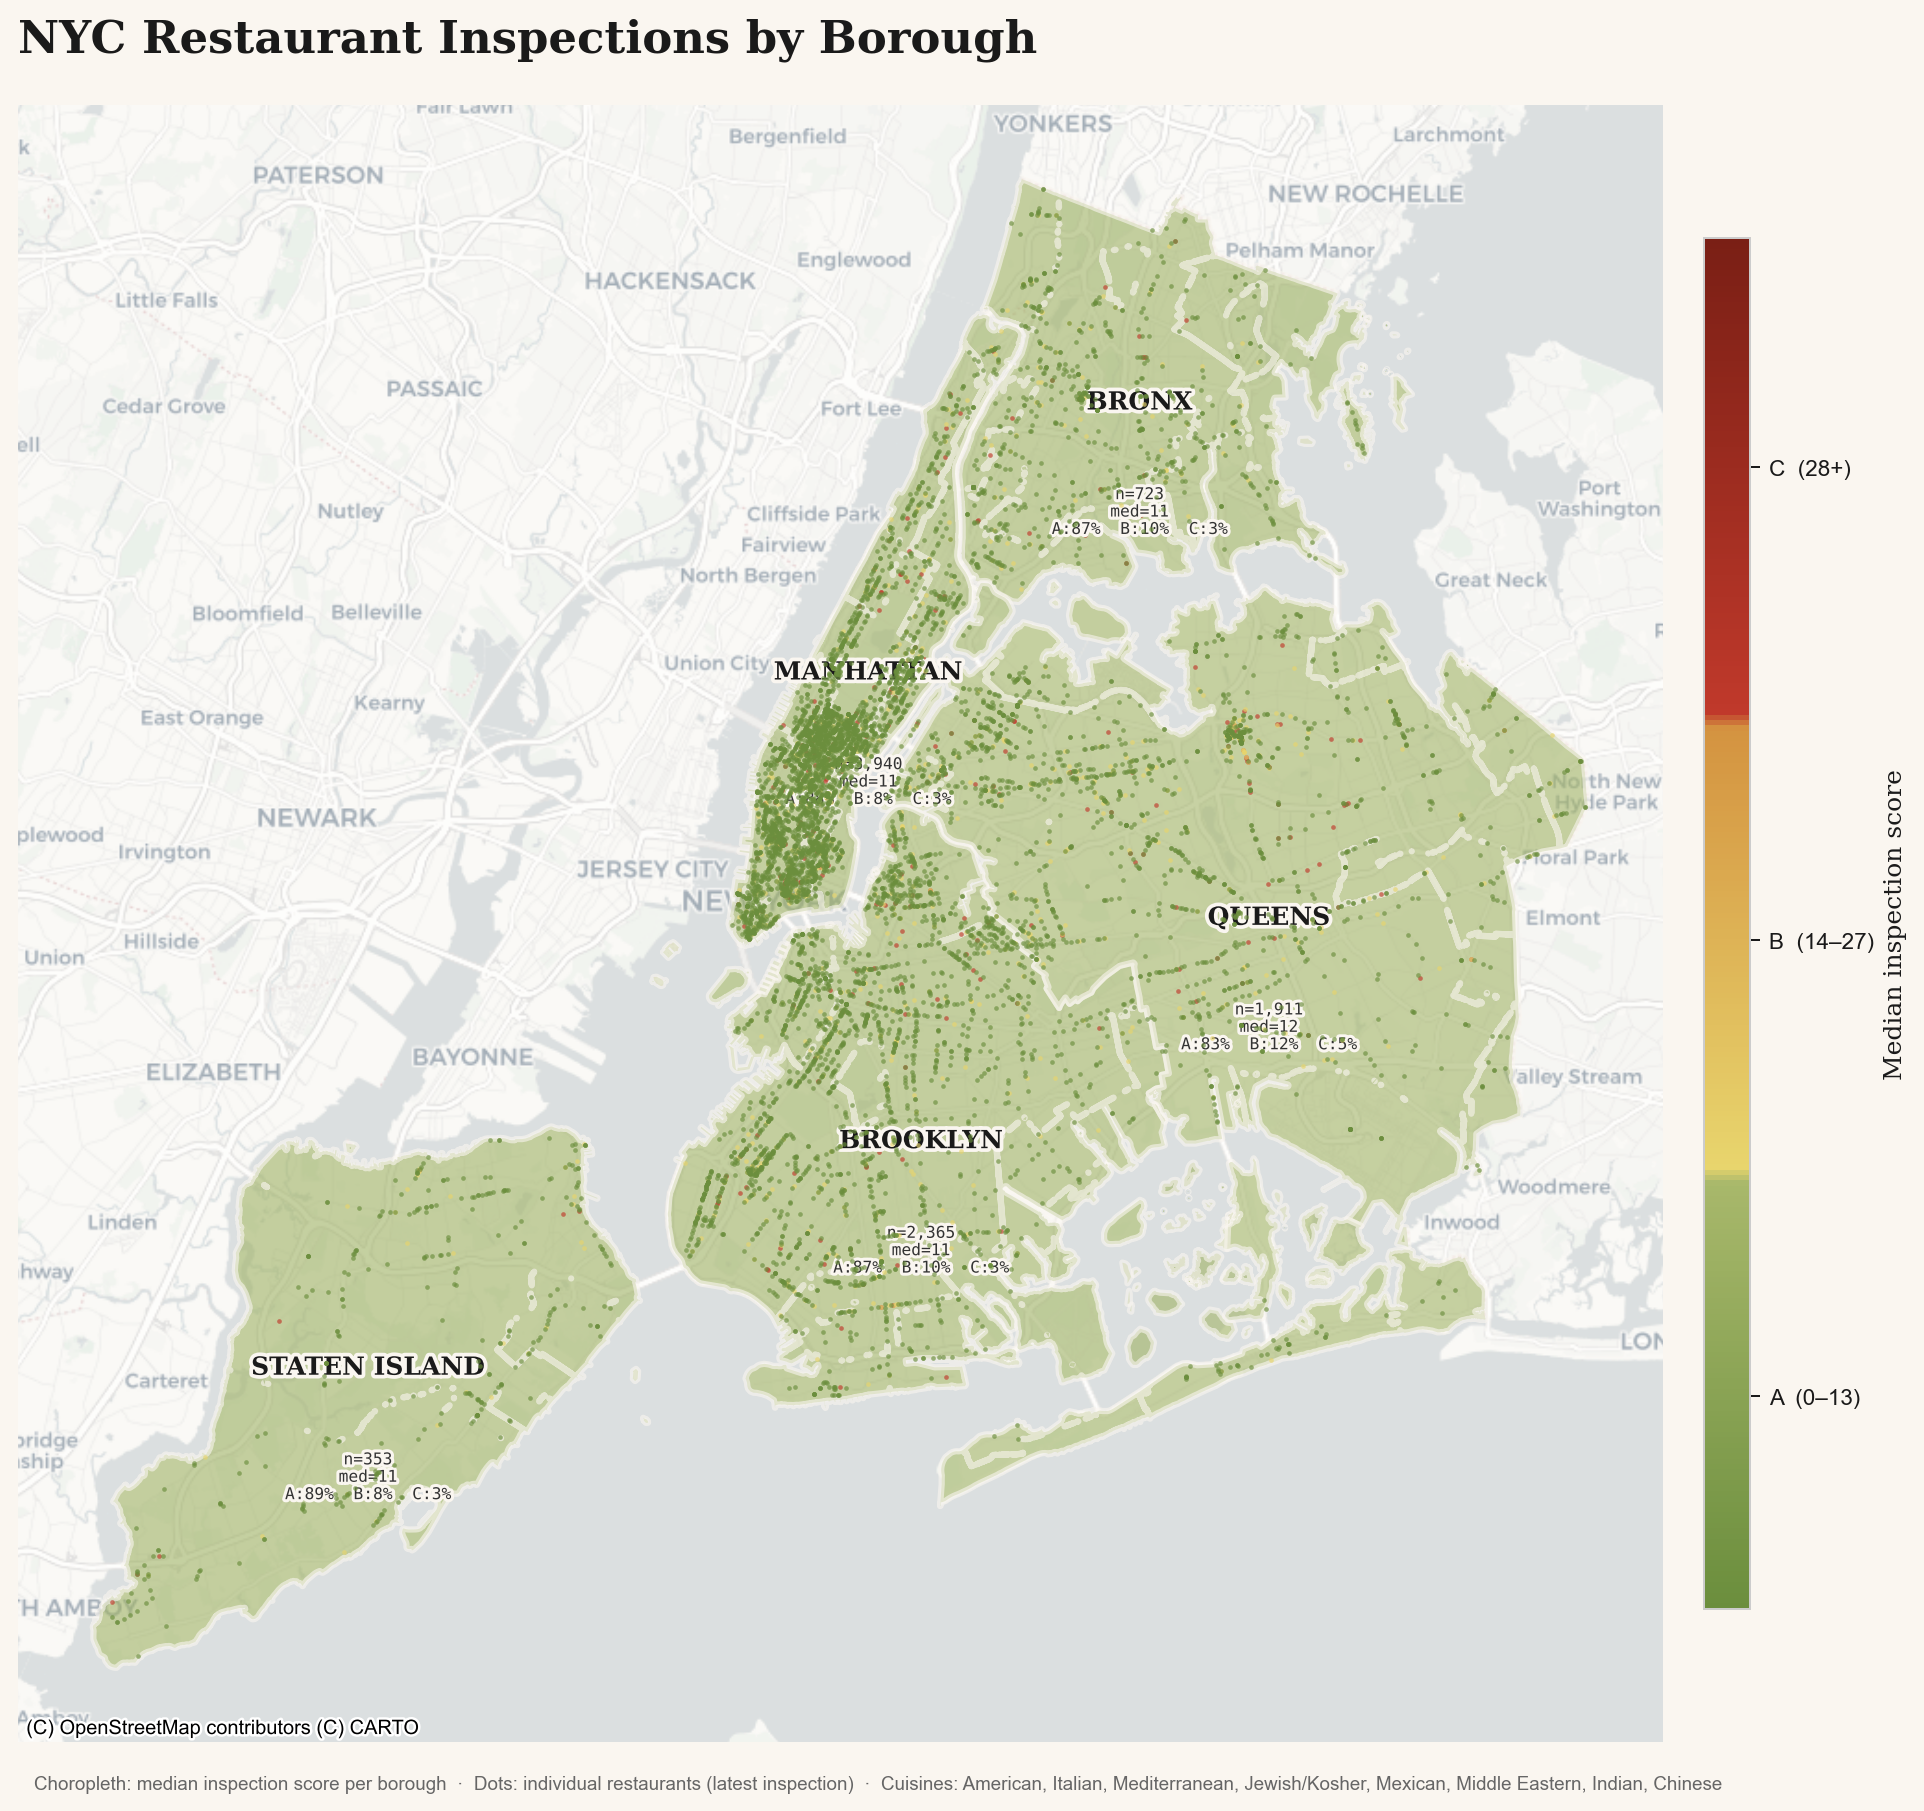

> **Figure 7:** is an interactive map that shows the distribution of restaurant sanitation quality in New York City's five boroughs. It shows each establishment's most recent gradable inspection score. The map also shows the median inspection score for each borough. The color scale ranges from green (high compliance, score = 0) to red (low compliance, score ≥ 20). The ivory transition point (score = 13 ± 1) represents the critical A/B grade boundary. Borough geometries were derived by dissolving 2020 Neighborhood Tabulation Area (NTA) data to ensure alignment with DOHMH administrative boundaries. The dashboard allows you to filter by eight major cuisine categories and specific letter grades. Hover over a borough to view localized metrics on restaurant density, grade distribution, and the dominant cuisine type. Note: This visualization is interactive. Use the multi-select menus to filter by cuisine or grade. Hover over a borough to view its detailed metadata.

### 3.6 Power law: do a few restaurants concentrate most of the penalty

Since broad cultural and geographical categories carry little predictive weight, we must examine the distribution of penalty points at the level of individual establishments. If violations were distributed evenly throughout the city, we would expect to see a normal distribution, or a bell curve. However, data from df_2026_no_covid suggests an extreme reality. We can quantify the degree of concentration in NYC’s sanitary landscape by applying a power-law analysis, a technique used to study phenomena such as wealth inequality and urban crime [3]. This analysis tests whether most of the "sanitary noise" in the city is produced by a few extreme violators. If a power law exists, then "average" inspection scores are statistically misleading because the typical experience is dominated by rare but extreme outliers.

N restaurants:            24,104
Total penalty points:     1,864,331
MLE α:                    1.22
Top 14.9% of restaurants account for 50% of all penalty points


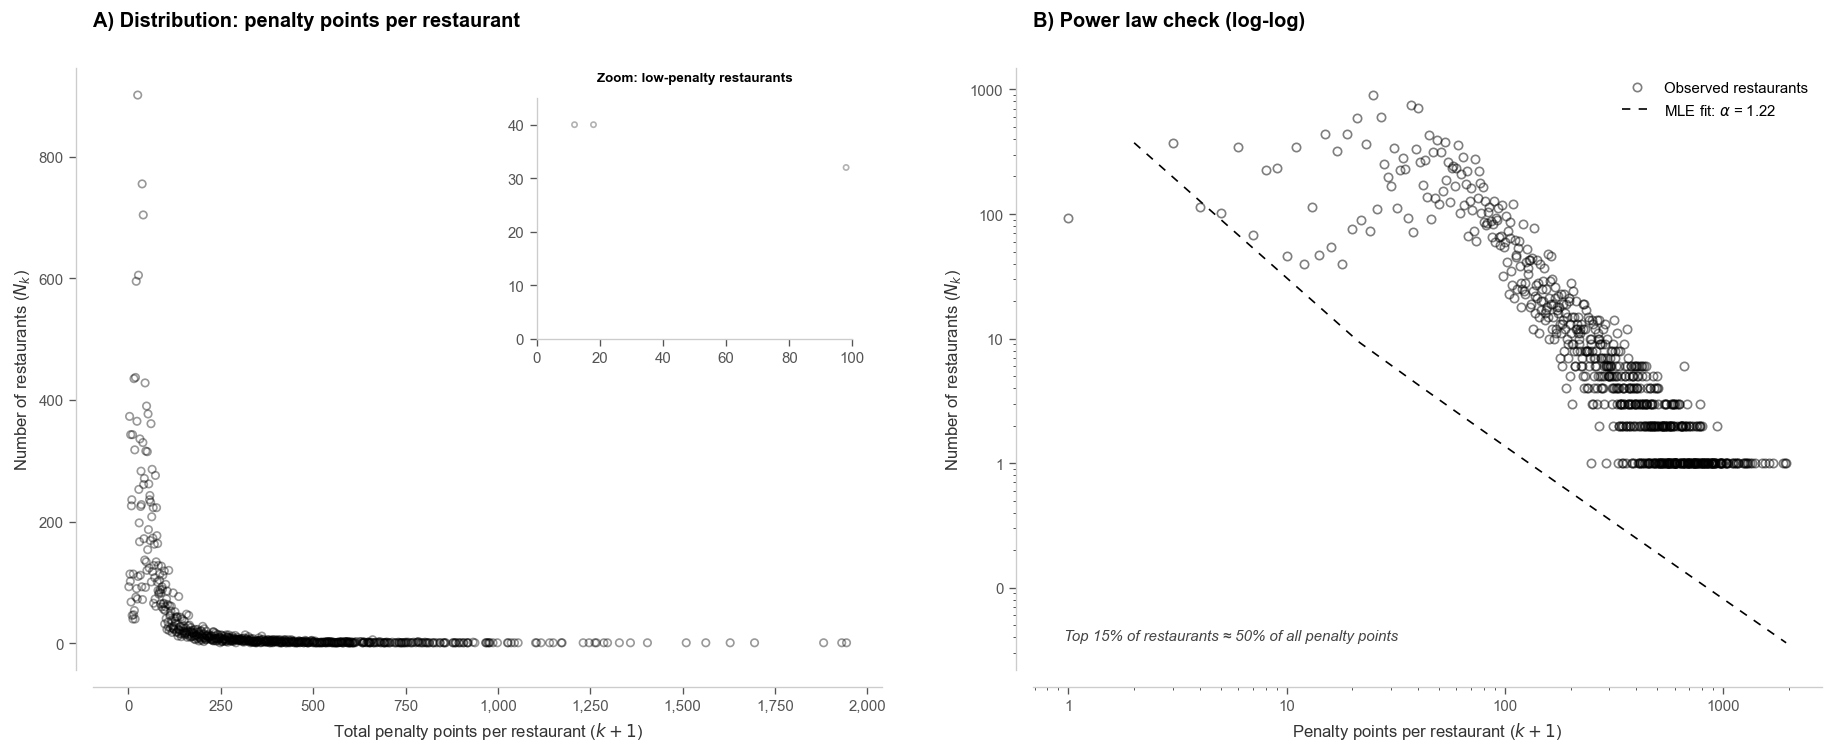

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# Plot N4 — Power law: do a few restaurants concentrate most of the penalty?
# Adapted from A1 Ex 1.4 (crime spatial concentration) → restaurant scores
# Methodology: Oliveira et al., 2017 (MLE for discrete power law)
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- DATA PREP ---
# Aggregate total penalty score per restaurant (CAMIS)
# Each row in df is one violation; SCORE is the inspection score that violation
# contributed to. Sum = total penalty points accumulated by the restaurant.
df_focus = df_2026_no_covid.dropna(subset=["SCORE", "CAMIS"]).copy()
df_focus["SCORE"] = pd.to_numeric(df_focus["SCORE"], errors="coerce")
df_focus = df_focus[df_focus["SCORE"] >= 0].dropna(subset=["SCORE"])

# Total accumulated penalty points per restaurant
restaurant_totals = df_focus.groupby("CAMIS")["SCORE"].sum().astype(int)

# k = penalty points per restaurant; N_k = number of restaurants with that total
counts = restaurant_totals.values
k_values, N_k = np.unique(counts, return_counts=True)

# --- MLE Alpha Calculation (Oliveira et al., 2017 methodology) ---
# Same formula as the crime exercise: continuous-approx MLE with x_min = 1
x_i = counts[counts > 0]
n = len(x_i)
alpha_mle = 1 + n * (np.sum(np.log(x_i / (1 - 0.5)))) ** -1

# --- Concentration summary (Pareto-style headline number) ---
sorted_totals = np.sort(counts)[::-1]
cum_share = np.cumsum(sorted_totals) / sorted_totals.sum()
top_share = (cum_share <= 0.50).sum() / len(sorted_totals) * 100
print(f"N restaurants:            {len(counts):,}")
print(f"Total penalty points:     {counts.sum():,}")
print(f"MLE α:                    {alpha_mle:.2f}")
print(f"Top {top_share:.1f}% of restaurants account for 50% of all penalty points")

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

def comma_fmt(x, p): return f"{int(x):,}"

# --- Plot A: Linear distribution + zoom inset ---
ax1.scatter(k_values + 1, N_k, color="black", alpha=0.4, s=20,
            facecolors="none", edgecolors="black")
ax1.set_xlabel("Total penalty points per restaurant ($k + 1$)", fontsize=10)
ax1.set_ylabel("Number of restaurants ($N_k$)", fontsize=10)
ax1.set_title("A) Distribution: penalty points per restaurant",
              loc="left", pad=25, fontsize=12, fontweight="bold")

# Inset zoom — focus on the bulk of low-scoring restaurants
ax_ins = inset_axes(ax1, width="40%", height="40%", loc="upper right", borderpad=2)
ax_ins.scatter(k_values + 1, N_k, color="black", alpha=0.3, s=10, facecolors="none")
ax_ins.set_xlim(0, 100)
ax_ins.set_ylim(0, N_k.max() * 0.05)
ax_ins.set_title("Zoom: low-penalty restaurants", fontsize=8)

# --- Plot B: Log-log + MLE trendline ---
ax2.loglog(k_values + 1, N_k, "o", color="black", alpha=0.5, markersize=5,
           mfc="none", label="Observed restaurants")

# MLE trendline anchored at k=1
k_range = np.linspace(1, max(k_values), 100)
C = N_k[k_values == 1][0] if any(k_values == 1) else N_k[1]
y_trend = C * (k_range) ** (-alpha_mle)
ax2.loglog(k_range + 1, y_trend, color="black", linestyle=(0, (5, 5)),
           linewidth=1, label=f"MLE fit: $\\alpha$ = {alpha_mle:.2f}")

ax2.set_xlabel("Penalty points per restaurant ($k + 1$)", fontsize=10)
ax2.set_ylabel("Number of restaurants ($N_k$)", fontsize=10)
ax2.set_title("B) Power law check (log-log)",
              loc="left", pad=25, fontsize=12, fontweight="bold")
ax2.legend(frameon=False, loc="upper right", fontsize=9)

# --- TUFTE AESTHETICS ---
for ax in [ax1, ax2, ax_ins]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if ax != ax_ins:
        ax.spines["left"].set_position(("outward", 10))
        ax.spines["bottom"].set_position(("outward", 10))
    ax.tick_params(direction="out", length=4, width=0.8, labelsize=9)
    ax.grid(False)

ax1.xaxis.set_major_formatter(FuncFormatter(comma_fmt))
ax1.yaxis.set_major_formatter(FuncFormatter(comma_fmt))
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.yaxis.set_major_formatter(ScalarFormatter())

# Annotation in plot B with the headline finding
ax2.text(0.04, 0.05,
         f"Top {top_share:.0f}% of restaurants ≈ 50% of all penalty points",
         transform=ax2.transAxes, fontsize=9, style="italic", color="#444")

plt.tight_layout(pad=3.0)
plt.show()

> **Figure 8:** Spatial Scaling and Concentration Behavior of Cumulative Restaurant Penalty Points
(A) The linear distribution of total penalty points (k) per restaurant (N_k) exhibits a heavily zero-inflated profile with an extended "long tail." (Inset) A close-up of low-penalty establishments (k < 100) showing the rapid frequency decay characteristic of non-Gaussian systems. (B) Power-law verification via log-log transformation. Using the discrete maximum likelihood estimation (MLE) methodology of Oliveira et al. (2017), the dashed fit line estimates a scaling exponent of α = 1.22. This scale-invariant distribution indicates extreme concentration. The top 15% of restaurants account for approximately 50% of all cumulative penalty points citywide. This suggests that sanitary risk in New York City is not a uniform "background" characteristic, but rather concentrated in a small minority of establishments whose behavior diverges radically from the citywide norm.

---

## 4 Genre: which genre of data story did you use? 

Our website uses a magazine-style layout with a martini glass narrative structure [4]. Text and visualizations are embedded together on a scrollable page, and the author guides the reader through a sequence of arguments similar to those in a data journalism article. The first three sections (box plots, Cleveland dot plots, and logistic regression) comprise the author-driven stem. This section walks the reader through a predetermined argument about hygiene bias. The final two sections (heat map and map) open up to reader-driven exploration and form the bowl.





### 4.1 Visual Narrative Tools
Visual narrative tactics are the visual devices that assist and facilitate the flow of the story.

* **Visual Structuring**
    * **Establishing Shot / Splash Screen:** The website uses a bold title and a hook (the Kahneman quote) to immediately set the scene and grab attention.
    * **Consistent Visual Platform:** As the user scrolls, the layout remains stable (text on the left/center, visualizations updating accordingly), which prevents the viewer from having to reorient between sections.
* **Highlighting**
    * **Feature Distinction:** You use color—specifically "warmer" and "cooler" hues—to distinguish between above-average and below-average scores in the heatmap, directing the eye to significant data points[cite: 66, 518].
    * **Zooming / Close-Ups:** The charts allow users to hover over specific data dots to reveal deeper information, effectively "zooming in" on specific data subsets.
* **Transition Guidance**
    * **Animated Transitions:** The project employs scrollytelling, where charts morph or update as the user moves through the page. This maintains "object continuity," helping the viewer understand how the previous data relates to the new view.





### 4.2 Narrative Structure Tools
Narrative structure tactics are the non-visual mechanisms that organize the story and define how the user interacts with it.

* **Ordering**
    * **Linear:** The initial part of the website follows a strict linear path—from the introduction to "What shapes a score?" to the predictive model—to ensure the author’s argument is understood first.
    * **User-Directed Path:** The final section ("Now You Try") switches to a user-directed path, allowing the reader to explore the map based on their own interests.
* **Interactivity**
    * **Hover Highlighting / Details-on-Demand:** Used throughout the charts to provide specific statistics without cluttering the main narrative.
    * **Filtering / Selection / Search:** The final map includes filters for Borough, Cuisine, and Grade, enabling free exploration.
    * **Explicit Instruction:** You provide clear prompts like "Scroll to see...", "Hover over the dots...", and "Use the... filters," which are essential for guiding a general audience through interactive data.
* **Messaging**
    * **Captions / Headlines:** Every section is clearly labeled (e.g., "Signature Plate", "Cuisine View"), which provides a "nut graf" or summary of the news value of that specific data point.
    * **Annotations:** Text is placed directly within or near the graphs to explain outliers or patterns, such as the note about the pandemic-era pause in grading.
    * **Summary / Synthesis:** The "What we learned" section at the end provides a final synthesis of the data, a common storytelling technique that reinforces the narrative's key takeaways.



---

## 5 Visualizations


> **Note:** We used a data-ink ratio and a DAOST style for the notebooks, meaning the process of creating all the web visualisations was different. While the data-ink ratio is ideal for technical reports, it is not suitable for creating colour palettes for webpages or presentations as it does not make them visually appealing. To see this process in action, open the 'WebPage_Visualisations.ipynb' file.


### 5.1 Explain the visualizations you've chosen and Why are they right for the story you want to tell?

* **Box plot — annotated chart:** This shows the full distribution of inspection scores by cuisine, including the median, range, and outliers, all within a single frame. The annotation reveals that the median score for cuisines that readers distrust is the same as for those they trust. A bar chart of averages would hide the variance that makes this finding surprising.

* **Cleveland Dot Plot — Slide Show:** Violation rates across five categories are presented one at a time, with an identical scale and layout throughout. This uses the consistent visual platform tactic. As only the data changes between panels, readers can focus entirely on comparing categories, without having to relearn how to read the chart.

* **Logistic Regression Widget — Annotated Chart:** Transforms a model into a personal experience. It distinguishes between weaker and dominant predictors, making the argument comprehensible to non-statisticians, too. Readers select the inputs, and the chart provides the conclusion.

* **Heat map — annotated chart:** The colour density shows each cuisine's score relative to the citywide average for that year. The visual highlighting reveals the anomaly for Asian cuisines during the pandemic era. Without the annotation linking it to the NYU enforcement study, the colour shift is interesting, but not explained. It is the annotation that transforms the pattern into a finding.

* **Interactive map — annotated graph/map:** The bowl of the martini glass. Readers can select a user-directed path by using the borough, cuisine and grade filters, giving them control. Dynamic summary statistics provide interpretive context throughout the free exploration process.

---

## 6 Discussion








### 6.1 What went well?

One of the most valuable outcomes of this project was that the data challenged our initial hypothesis.

At the beginning, we expected to find a clear relationship between restaurant inspection scores, cuisine type, and neighborhood. Based on common social perceptions, we assumed certain cuisines or boroughs would systematically receive worse scores. However, after cleaning and exploring the dataset, those assumptions were not supported by the data.

Rather than forcing the data to confirm our expectations, we allowed the evidence to reshape the story. This became one of the strongest aspects of the project: instead of telling a story about restaurant cleanliness, we ended up telling a story about human bias and how easily we create patterns where none may exist.

This shift allowed us to transform an initially descriptive analysis into a more engaging narrative with a psychological dimension.

From a technical perspective, we successfully handled a noisy real-world dataset, resolved inconsistencies across inspection records, and engineered features that helped us better understand long-term restaurant behavior.

Our exploration led to several important findings:

- Most restaurants maintain consistently strong inspection outcomes over time.
- Common stereotypes about cuisine types or neighborhoods were not supported by the data.
- Historical inspection performance was a stronger predictor of future scores than location or cuisine.

Furthermore, incorporating external contextual data, such as demographic and population information, into the analysis allowed us to challenge our assumptions and consider the data from a broader social standpoint.

### 6.2 What could be improved?

Although the final story was data-driven and engaging, several aspects could be improved.

First, the project would benefit from stronger academic grounding in cognitive bias and consumer perception. While we used intuitive examples of human bias, we would have liked to support these interpretations with formal studies from fields such as Behavioral Economics, Cognitive Psychology, or consumer behavior research.

For example, it would be valuable to investigate whether restaurant cleanliness perception has been formally studied, and whether visual or cultural cues systematically affect consumer trust.

Secondly, some of the patterns observed during extraordinary events, such as pandemics or disease outbreaks, are merely correlational rather than causal. While these patterns are interesting from a storytelling perspective, stronger conclusions would require further statistical analysis.

From a storytelling perspective, one challenge is that the effort invested in data exploration does not always translate directly into audience engagement. Topics such as restaurant inspections may not immediately attract attention compared to more emotionally charged subjects such as crime, politics, or finance.

This highlighted an important lesson:

> A story is not only about presenting interesting data, it is about connecting the data to something people already care about.

In our case, connecting restaurant inspections to personal bias and everyday decision-making helped bridge that gap. However, audience testing would help validate whether this narrative truly resonates with users.

### 6.3 Future Work

Future improvements could include:

- Applying statistical significance testing to validate observed patterns.
- Integrating surveys to compare user perceptions against actual inspection data.
- Including academic literature on bias, risk perception, and consumer trust.
- Measuring user interaction with the web application to understand which visualizations generate the strongest engagement.
- Expanding the analysis to other cities to test whether these behavioral patterns generalize beyond New York City.

---

## 7 Contributions 

Juan Manuel Rodriguez (S253505) led the exploratory data analysis. This involved cleaning the data, adjusting for survivorship bias, and producing key statistical summaries. He was the primary author of the box plot and the Cleveland dot plot, overseeing everything from the analytical framework to the final visual design. He also co-developed the website's narrative structure and interactive map with Guillermo.

Guillermo Quiroga Ocaña (S252802) led the advanced modelling work, which involved power law analysis using maximum likelihood estimation (MLE) and logistic regression classification. He was the primary developer of the website, responsible for its implementation and visual design. He also co-developed the narrative structure and interactive map with Juan Manuel.

Although the above outlines the main responsibilities, both members were involved in and familiar with all aspects of the project. Key decisions, such as the choice of dataset, the Martini glass narrative structure, and the selection of visualisations, were made jointly throughout the project.

---
## References

[1] New York City Department of Health and Mental Hygiene. (2026). DOHMH New York City restaurant inspection results [Data set]. NYC OpenData. Retrieved April 30, 2026, from https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data

[2] Tzioumis, K. (2019). New-York-Restaurant-Guide [Computer software]. GitHub. https://github.com/ktzioumis/New-York-Restaurant-Guide/tree/master

[3] Oliveira, M., Bastos-Filho, C., & Menezes, R. (2017). The scaling of crime concentration in cities. PLOS ONE, 12(8), e0183110. https://doi.org/10.1371/journal.pone.0183110

[4] Segel, E., & Heer, J. (2010). Narrative visualization: Telling stories with data. IEEE Transactions on Visualization and Computer Graphics, 16(6), 1139–1148. https://doi.org/10.1109/TVCG.2010.179


---
## Use of AI

The technical implementation and presentation of this assignment involved the use of generative AI tools in the following capacities:

* Plotting and Visualization: AI was utilized to assist in refining the plotting code (Matplotlib, Seaborn, and Altair), specifically for optimizing the data-ink ratio, adjusting aesthetic parameters, and troubleshooting complex multi-panel figures.

* Text Refinement: Generative AI was used as a linguistic assistant to verify grammar, improve sentence structure, and ensure clarity throughout the report.

* Verification and Accountability: Every output generated or assisted by AI including code logic, statistical calculations, and text was thoroughly reviewed and verified by the authors. All interpretations, insights, and final conclusions were developed by the authors to ensure the work accurately reflects our analysis of the  dataset.